# NASA Kepler Dışgezegen Sınıflandırması — Eksiksiz Makine Öğrenmesi İş Akışı

Bu notebook; Kepler İlgi Nesnelerini (KOI) üç kategoriye sınıflandırmak için temiz ve veri sızıntısı içermeyen bir makine öğrenmesi iş akışı uygular: ONAYLANDI (CONFIRMED), ADAY (CANDIDATE) ve YANLIŞ POZİTİF (FALSE POSITIVE).

Tüm ön işleme adımları, veri sızıntısını önlemek amacıyla sklearn Pipeline nesneleri içine gömülmüştür.

## Kurulum ve Kütüphane İçe Aktarımı

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import time
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from importlib import import_module

# Sklearn içe aktarımları
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.datasets import make_moons
from types import SimpleNamespace

# Model içe aktarımları
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

# XGBoost içe aktarmayı dene
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# Optuna içe aktarmayı dene
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

# Imbalanced-learn içe aktarmayı dene 
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    SMOTE = None
    IMBLEARN_AVAILABLE = False

# SHAP içe aktarmayı dene
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# ========== HATA AYIKLAMA MODU ==========
DEBUG_MODE = False

# Yapılandırma
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

CLASS_ORDER = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

CLASS_PALETTE = {
    "CANDIDATE": "#F59E0B",       # yellow/orange
    "CONFIRMED": "#16A34A",       # green
    "FALSE POSITIVE": "#DC2626"   # red
}

CLASS_PALETTE_LIGHT = {
    "CANDIDATE": "#FDE68A",
    "CONFIRMED": "#BBF7D0",
    "FALSE POSITIVE": "#FECACA"
}

STAGE_PALETTE = {
    "Baseline": "#94A3B8",
    "Tuned": "#2563EB"
}

RESULT_PALETTE = {
    "Correct": "#16A34A",
    "Misclassified": "#DC2626"
}

class_stage_palettes = {
    class_name: {
        "Baseline": CLASS_PALETTE_LIGHT[class_name],
        "Tuned": CLASS_PALETTE[class_name]
    }
    for class_name in CLASS_ORDER
}

# DEBUG_MODE'a göre koşullu ayarlar
if DEBUG_MODE:
    CV_SPLITS = 2
    print('⚠️ DEBUG_MODE is ON — Using reduced CV_SPLITS and search iterations')
else:
    CV_SPLITS = 5

# Veriyi yükle
df = pd.read_csv('exoplanets_pull.csv')
print(f'✓ Dataset loaded: {df.shape}')

# Ön işleme için özel dönüştürücüler

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        return X_df.drop(columns=self.columns, errors='ignore')

class MedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.imputer = SimpleImputer(strategy='median')
        self.num_cols_ = None
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        if self.num_cols_:
            self.imputer.fit(X_df[self.num_cols_])
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if self.num_cols_:
            X_df[self.num_cols_] = self.imputer.transform(X_df[self.num_cols_])
        return X_df

class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skewed_cols):
        self.skewed_cols = skewed_cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        for col in self.skewed_cols:
            if col in X_df.columns:
                X_df[col] = np.log1p(X_df[col].clip(lower=0))
        return X_df

class OutlierClipper(BaseEstimator, TransformerMixin):
    """Aykırı değerleri yalnızca eğitim seti yüzdeliklerine göre kırpar (eğitim setine uyarlanır)"""
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q
        self.bounds_ = None
        self.num_cols_ = None
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        self.bounds_ = {}
        for col in self.num_cols_:
            self.bounds_[col] = (
                X_df[col].quantile(self.lower_q),
                X_df[col].quantile(self.upper_q)
            )
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if self.bounds_:
            for col, (lower, upper) in self.bounds_.items():
                if col in X_df.columns:
                    X_df[col] = X_df[col].clip(lower=lower, upper=upper)
        return X_df

def build_preprocessing_pipeline(skewed_cols):
    """Ön işleme adımlarını oluşturup döndürür (tek bir Pipeline'a düzleştirme için)."""
    steps = [
        ('drop', DropColumns(drop_cols)),
        ('imputer', MedianImputer()),
        ('log', LogTransformer(skewed_cols)),
        ('clip', OutlierClipper(lower_q=0.01, upper_q=0.99)),
        ('scaler', StandardScaler()),
    ]
    # SMOTE, ölçeklendirme tamamlansın diye modelden önce son ön işleme adımı olmalıdır.
    if IMBLEARN_AVAILABLE and SMOTE is not None:
        steps.append(('smote', SMOTE(random_state=42, k_neighbors=5)))
    return steps

print('✓ Ön işleme hattı tanımlandı')
print('  Adımlar:')
print('    1. Sütunları kaldır (veri sızıntısı + gereksiz bilgiler)')
print('    2. Median imputasyonu')
print('    3. Log1p dönüşümü çarpık özellikler için')
print('    4. Aykırı değer kırpma (yalnızca eğitim verisinde uyarlanır)')
print('    5. Standart ölçekleme')
print('    6. SMOTE (yalnızca eğitim verisi, ölçeklendirmeden sonra uygulanır)')
print('\n  Tüm dönüştürücüler yalnızca eğitim verisi üzerinde uyarlanır → veri sızıntısını önler')

✓ Dataset loaded: (9564, 27)
✓ Ön işleme hattı tanımlandı
  Adımlar:
    1. Sütunları kaldır (veri sızıntısı + gereksiz bilgiler)
    2. Median imputasyonu
    3. Log1p dönüşümü çarpık özellikler için
    4. Aykırı değer kırpma (yalnızca eğitim verisinde uyarlanır)
    5. Standart ölçekleme
    6. SMOTE (yalnızca eğitim verisi, ölçeklendirmeden sonra uygulanır)

  Tüm dönüştürücüler yalnızca eğitim verisi üzerinde uyarlanır → veri sızıntısını önler


## 1. Keşifsel Veri Analizi (EDA) ve İstatistiksel Analiz

### 1.1 Veri Kümesine Genel Bakış

In [61]:
# Veri kümesinin boyutunu, sütunlarını ve ilk satırlarını yazdır
print('Dataset Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst few rows:')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

Dataset Shape: (9564, 27)

Columns: ['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_slogg', 'koi_srad', 'ra', 'dec', 'koi_kepmag']

First few rows:


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,1.0,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,2.0,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,1.0,q1_q17_dr25_tce,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,1.0,q1_q17_dr25_tce,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,1.0,q1_q17_dr25_tce,6031.0,4.438,1.046,288.75488,48.226200,15.509



Data types:


,dtype
kepid,int64
kepoi_name,str
kepler_name,str
koi_disposition,str
koi_pdisposition,str
koi_score,float64
koi_fpflag_nt,int64
koi_fpflag_ss,int64
koi_fpflag_co,int64
koi_fpflag_ec,int64


### 1.2 Eksik Değerler

In [62]:
# Eksik değer sayısını ve yüzdesini hesapla
missing_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print('Missing Values:')
display(missing_report[missing_report['Missing Count'] > 0])

Missing Values:


,Missing Count,Missing %
kepler_name,6817,71.28
koi_score,1510,15.79
koi_teq,363,3.80
koi_srad,363,3.80
koi_slogg,363,3.80
koi_steff,363,3.80
koi_model_snr,363,3.80
koi_impact,363,3.80
koi_depth,363,3.80
koi_prad,363,3.80


### 1.3 Betimsel İstatistikler

In [63]:
# Betimsel istatistikleri hesapla; medyanı da ekle
desc = df.describe().T
desc['median'] = df.median(numeric_only=True)
stats_table = desc[['mean', 'std', 'median', 'min', 'max']]
display(stats_table.round(3))

,mean,std,median,min,max
kepid,7690628.327,2653459.081,7906892.000,757450.000,1.293514e+07
koi_score,0.481,0.477,0.334,0.000,1.000000e+00
koi_fpflag_nt,0.209,4.767,0.000,0.000,4.650000e+02
koi_fpflag_ss,0.233,0.423,0.000,0.000,1.000000e+00
koi_fpflag_co,0.198,0.398,0.000,0.000,1.000000e+00
koi_fpflag_ec,0.120,0.325,0.000,0.000,1.000000e+00
koi_period,75.671,1334.744,9.753,0.242,1.299958e+05
koi_time0bk,166.183,67.919,137.225,120.516,1.472522e+03
koi_impact,0.735,3.349,0.537,0.000,1.008060e+02
koi_duration,5.622,6.472,3.793,0.052,1.385400e+02


### 1.4 Hedef Sınıf Dağılımı

Target Class Distribution:
koi_disposition
CANDIDATE         1978
CONFIRMED         2747
FALSE POSITIVE    4839
Name: count, dtype: int64

Percentages:
koi_disposition
CANDIDATE         20.68
CONFIRMED         28.72
FALSE POSITIVE    50.60
Name: count, dtype: float64


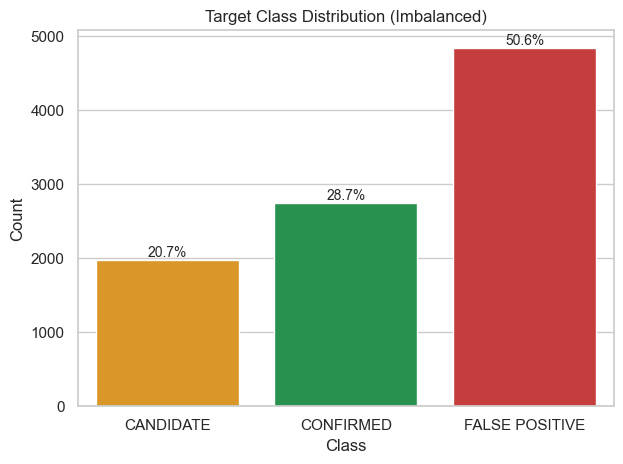


✓ Veri setinde orta düzeyde sınıf dengesizliği vardır.
  → Stratified split gereklidir
  → Macro F1 ana metriktir


In [2]:
# Hedef sütunu tanımla ve sınıf dağılımını hesapla
target_col = 'koi_disposition'
target_counts = df[target_col].value_counts().reindex(CLASS_ORDER)
target_pct = (target_counts / len(df) * 100).round(2)

print('Target Class Distribution:')
print(target_counts)
print('\nPercentages:')
print(target_pct)

ax = sns.countplot(
    data=df,
    x=target_col,
    hue=target_col,
    order=CLASS_ORDER,
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    legend=False
)
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, count), 
                ha='center', va='bottom', fontsize=10)

plt.title('Target Class Distribution (Imbalanced)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('\n✓ Veri setinde orta düzeyde sınıf dengesizliği vardır.')
print('  → Stratified split gereklidir')
print('  → Macro F1 ana metriktir')

### 1.5 Özellik Dağılımları ve Çarpıklık

In [5]:
# Sızıntı sütunlarını ve meta veri sütunlarını belirle
leakage_cols = [
    'koi_pdisposition', 'koi_score', 'koi_fpflag_nt',
    'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
]
id_meta_cols = ['kepid', 'kepoi_name', 'kepler_name', 'koi_tce_delivname']
drop_cols = [target_col] + leakage_cols + id_meta_cols

X_eda = df.drop(columns=drop_cols).copy()
y_eda = df[target_col].copy()
numeric_cols = X_eda.select_dtypes(include='number').columns.tolist()

print(f'Features for EDA: {X_eda.shape[1]}')
print(f'Numeric features: {len(numeric_cols)}')

# Çarpıklık analizi
skewness = X_eda[numeric_cols].skew().sort_values(ascending=False)
skewed_cols = skewness[skewness.abs() > 1].index.tolist()

print(f'\nHighly skewed features (|skewness| > 1): {len(skewed_cols)}')
print(skewed_cols)


Features for EDA: 16
Numeric features: 16

Highly skewed features (|skewness| > 1): 12
['koi_period', 'koi_prad', 'koi_insol', 'koi_impact', 'koi_srad', 'koi_duration', 'koi_model_snr', 'koi_depth', 'koi_time0bk', 'koi_tce_plnt_num', 'koi_teq', 'koi_slogg']


### 1.6 Korelasyon Matrisi

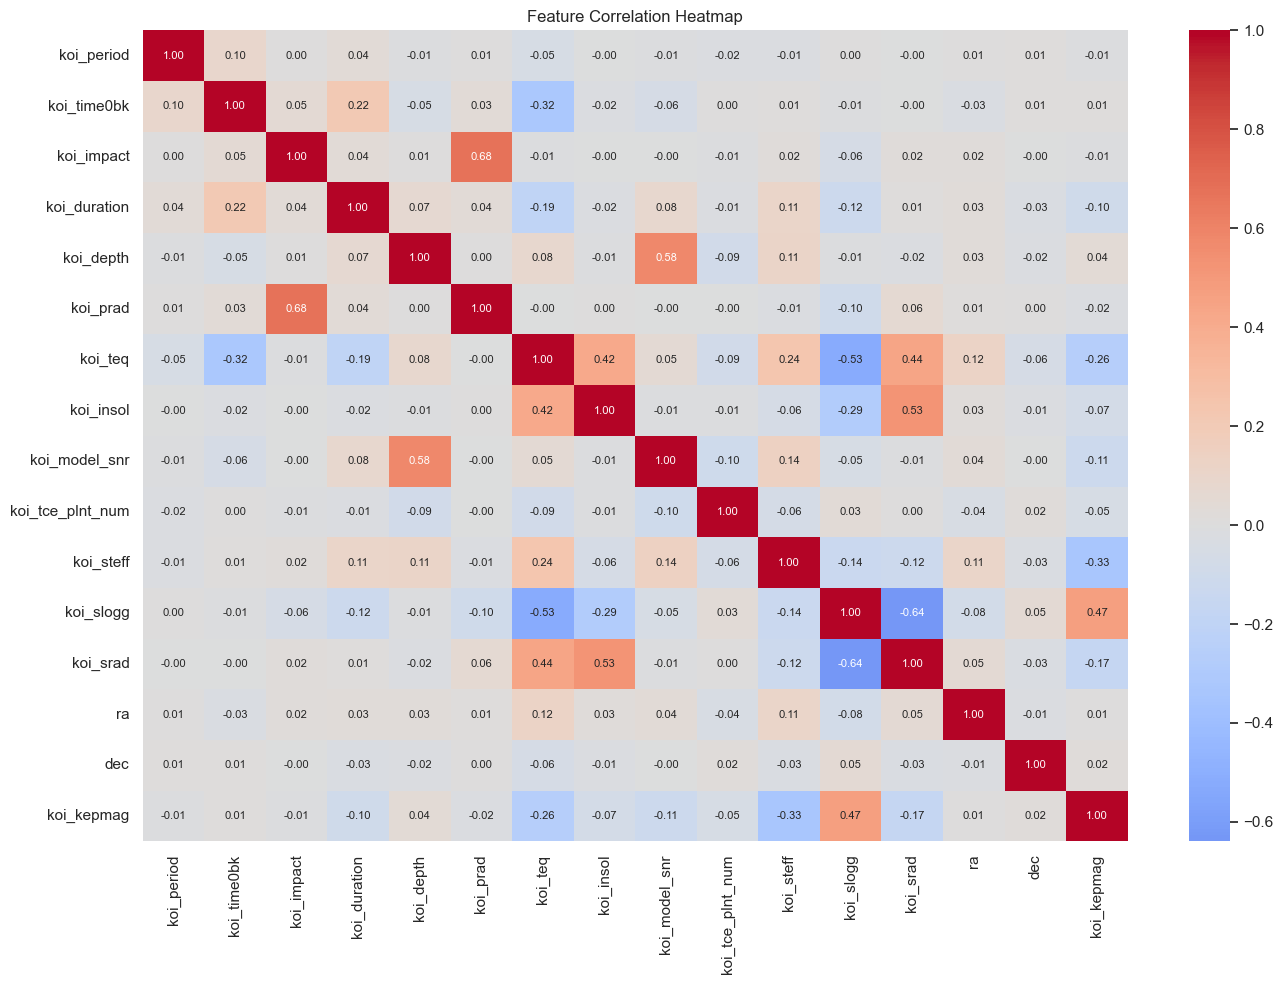

✓ Ciddi çoklu doğrusal bağlantı tespit edilmedi (❌ |r| > 0.85)


In [6]:
# Sayısal özellikler arasındaki korelasyon matrisini hesapla
corr = X_eda[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Yüksek korelasyonlu özellik çiftlerini bul (> 0.85)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr_pairs:
    print('⚠️ High correlation pairs detected (|r| > 0.85):')
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f'  - {feat1} ↔ {feat2}: {corr_val:+.4f}')
else:
    print('✓ Ciddi çoklu doğrusal bağlantı tespit edilmedi (❌ |r| > 0.85)')

### 1.7 Özellik - Hedef İlişkisi Analizi

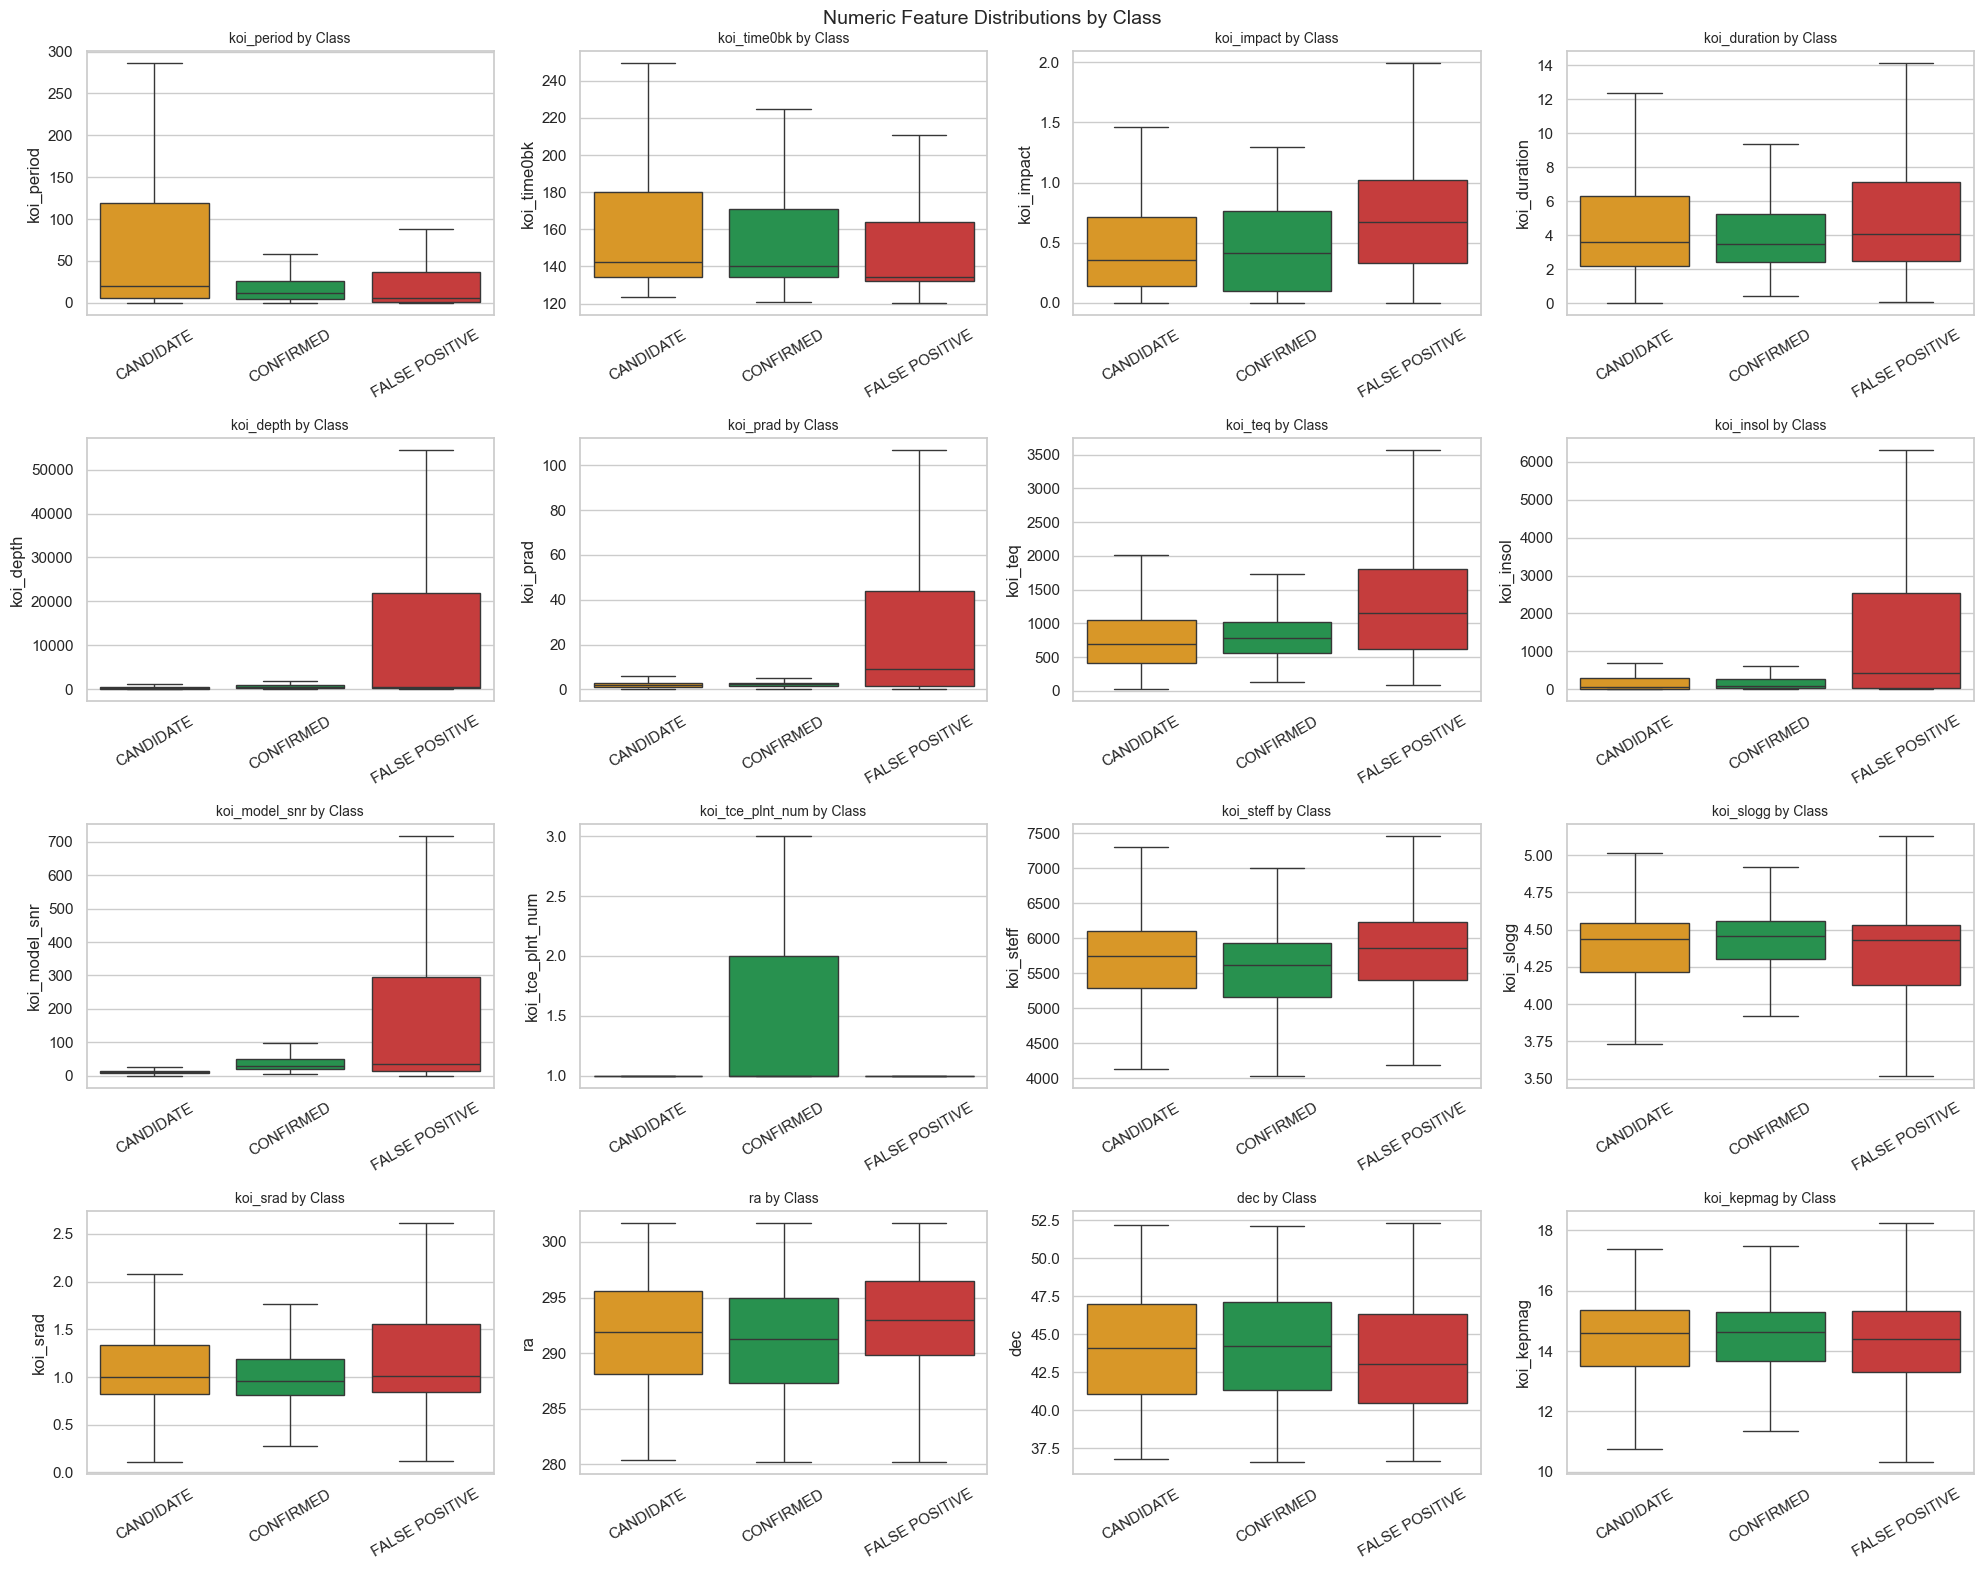

✓ Sınıfa göre özellik dağılımı analizi tamamlandı.
  → Boxplotlar, her sayısal özelliğin hedef sınıflar arasında nasıl değiştiğini gösterir.
  → Aykırı değerler okunabilirliği artırmak için gizlenmiştir.
  → Üst üste binen kutular, sınıflar arasında ayrılması daha zor olabilecek özellikleri gösterir.


In [7]:
# Her sayısal özelliğin sınıfa göre dağılımını kutu grafikleriyle görselleştir
df_plot = X_eda.copy()
df_plot['target'] = y_eda

features_to_plot = numeric_cols

n_cols = 4
n_rows = int(np.ceil(len(features_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(
        x='target',
        y=col,
        data=df_plot,
        ax=axes[i],
        order=CLASS_ORDER,
        palette=CLASS_PALETTE,
        showfliers=False
    )
    axes[i].set_title(f'{col} by Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Numeric Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

print('✓ Sınıfa göre özellik dağılımı analizi tamamlandı.')
print('  → Boxplotlar, her sayısal özelliğin hedef sınıflar arasında nasıl değiştiğini gösterir.')
print('  → Aykırı değerler okunabilirliği artırmak için gizlenmiştir.')
print('  → Üst üste binen kutular, sınıflar arasında ayrılması daha zor olabilecek özellikleri gösterir.')

## 2. Veri Sızıntısı Sütunlarının Kaldırılması

In [ ]:
# Kaldırılan sızıntı ve meta veri sütunlarını listele
print('Leakage columns (kaldırıldı):')
for col in leakage_cols:
    print(f'  - {col}')

print('\nMetadata columns (kaldırıldı):')
for col in id_meta_cols:
    print(f'  - {col}')

print(f'\nTarget column: {target_col}')
print(f'\nRemaining features: {len(numeric_cols)}')

Leakage columns (removed):
  - koi_pdisposition
  - koi_score
  - koi_fpflag_nt
  - koi_fpflag_ss
  - koi_fpflag_co
  - koi_fpflag_ec

Metadata columns (removed):
  - kepid
  - kepoi_name
  - kepler_name
  - koi_tce_delivname

Target column: koi_disposition

Remaining features: 16


## 3. Eğitim-Test Ayrımı

In [8]:
# X ve y'yi hazırla
X = df.drop(columns=drop_cols)
y = df[target_col].copy()

# Ham etiketler üzerinde tabakalı eğitim-test ayrımı (kodlamadan ÖNCE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# LabelEncoder'ı yalnızca eğitim verisiyle uyarla (bölmeden sonra)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

train_pct = len(X_train) / len(df) * 100
test_pct = len(X_test) / len(df) * 100

print(f'Train set: {X_train.shape[0]} samples ({train_pct:.1f}%)')
print(f'Test set: {X_test.shape[0]} samples ({test_pct:.1f}%)')

print('\nClass dağılımı (train):')
for idx, cnt in pd.Series(y_train).value_counts(sort=False).items():
    pct = cnt / len(y_train) * 100
    print(f'  {le.classes_[idx]}: {cnt} ({pct:.1f}%)')

print('\nClass dağılımı (test):')
for idx, cnt in pd.Series(y_test).value_counts(sort=False).items():
    pct = cnt / len(y_test) * 100
    print(f'  {le.classes_[idx]}: {cnt} ({pct:.1f}%)')

print('\n✓ Stratified split başarılı — class oranları korundu')

Train set: 7651 samples (80.0%)
Test set: 1913 samples (20.0%)

Class dağılımı (train):
  FALSE POSITIVE: 3871 (50.6%)
  CANDIDATE: 1582 (20.7%)
  CONFIRMED: 2198 (28.7%)

Class dağılımı (test):
  FALSE POSITIVE: 968 (50.6%)
  CONFIRMED: 549 (28.7%)
  CANDIDATE: 396 (20.7%)

✓ Stratified split başarılı — class oranları korundu


## 3.5 Özellik Mühendisliği

Gezegensel özellikler arasındaki anlamlı ilişkileri yakalamak için oran özellikleri oluşturun. Bu oranlar, dışgezegen sınıflandırması için ek tahmin sinyalleri sağlamak amacıyla türetilmiştir.

Yeni oran özellikleri X_train ve X_test setlerine eklendi:
['koi_prad_srad_ratio', 'koi_snr_depth_ratio', 'koi_insol_teq_ratio']
Yeni özelliklerin çarpıklık değerleri (eğitim):
{'koi_prad_srad_ratio': 26.763013063962376, 'koi_snr_depth_ratio': 5.930186954480733, 'koi_insol_teq_ratio': 34.71908297300231}
Güncellenmiş numeric_cols uzunluğu: 19
Güncellenmiş skewed_cols uzunluğu: 15


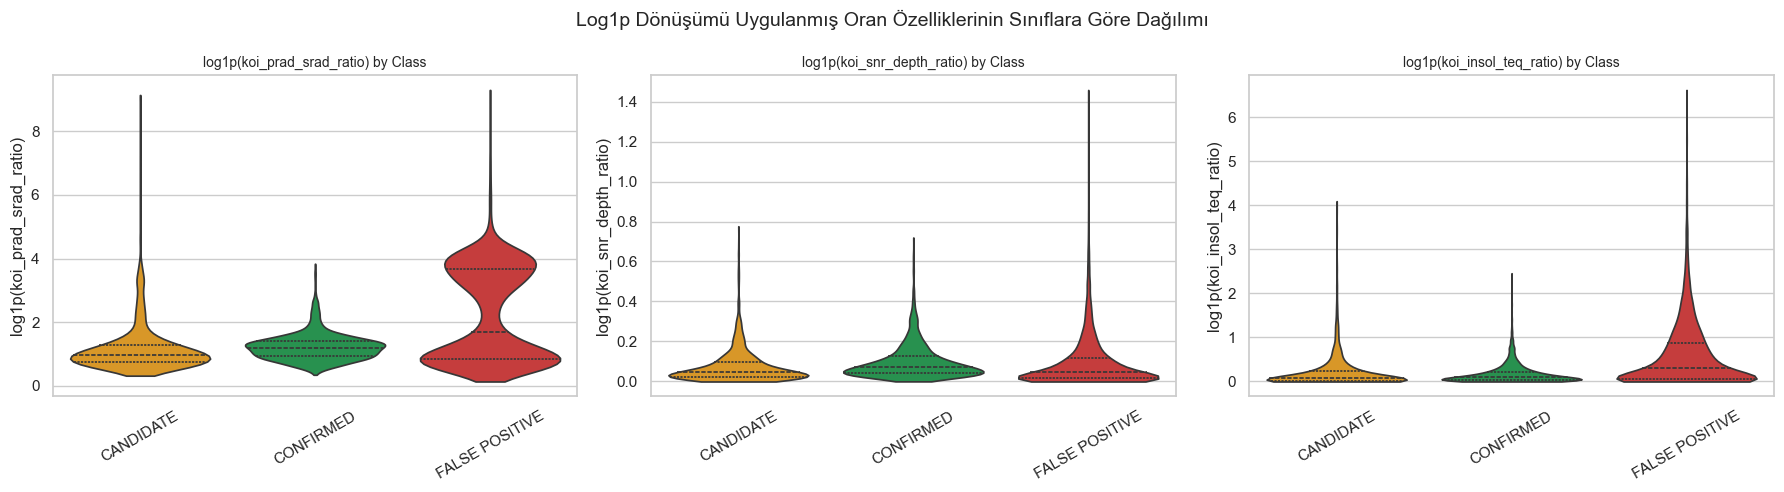

In [9]:
# === Özellik Mühendisliği: eğitim ve test setine oran özellikleri ekle ===
new_cols = ["koi_prad_srad_ratio", "koi_snr_depth_ratio", "koi_insol_teq_ratio"]

# Eğitim setinde oranları oluştur
# koi_prad_srad_ratio: Gezegenin yarıçapının yıldız yarıçapına oranı (büyük oran = yıldıza göre daha büyük gezegen)
X_train["koi_prad_srad_ratio"] = X_train['koi_prad'] / (X_train['koi_srad'] + 1e-6)

# koi_snr_depth_ratio: Sinyal-gürültü oranının transit derinliğine oranı (yüksek = daha net transit sinyali)
X_train["koi_snr_depth_ratio"] = X_train['koi_model_snr'] / (X_train['koi_depth'] + 1e-6)

# koi_insol_teq_ratio: Işınım akısının denge sıcaklığına oranı (yıldız enerji etkisini yakalar)
X_train["koi_insol_teq_ratio"] = X_train['koi_insol'] / (X_train['koi_teq'] + 1e-6)

# Aynı dönüşümleri test setine uygula (sızıntı yok)
X_test["koi_prad_srad_ratio"] = X_test['koi_prad'] / (X_test['koi_srad'] + 1e-6)
X_test["koi_snr_depth_ratio"] = X_test['koi_model_snr'] / (X_test['koi_depth'] + 1e-6)
X_test["koi_insol_teq_ratio"] = X_test['koi_insol'] / (X_test['koi_teq'] + 1e-6)

# Eğitim çarpıklığına göre numeric_cols ve skewed_cols'u güncelle
for c in new_cols:
    if c not in numeric_cols:
        numeric_cols.append(c)

# Eğitim çarpıklığını kontrol et; |çarpıklık| > 1 ise skewed_cols'a ekle
new_skew = X_train[new_cols].skew().abs()

for c, val in new_skew.items():
    if val > 1 and c not in skewed_cols:
        skewed_cols.append(c)

print('Yeni oran özellikleri X_train ve X_test setlerine eklendi:')
print(new_cols)
print('Yeni özelliklerin çarpıklık değerleri (eğitim):')
print(new_skew.to_dict())
print('Güncellenmiş numeric_cols uzunluğu:', len(numeric_cols))
print('Güncellenmiş skewed_cols uzunluğu:', len(skewed_cols))


# === Görselleştirme: sınıfa göre log1p-dönüştürülmüş oran özellikleri ===
df_ratio_plot = X_train[new_cols].copy()

for col in new_cols:
    df_ratio_plot[col] = np.log1p(df_ratio_plot[col].clip(lower=0))

df_ratio_plot["target"] = le.inverse_transform(y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(new_cols):
    sns.violinplot(
        x="target",
        y=col,
        data=df_ratio_plot,
        ax=axes[i],
        order=CLASS_ORDER,
        palette=CLASS_PALETTE,
        inner="quartile",
        cut=0
    )
    axes[i].set_title(f"log1p({col}) by Class", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(f"log1p({col})")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Log1p Dönüşümü Uygulanmış Oran Özelliklerinin Sınıflara Göre Dağılımı", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Ön İşleme Pipeline'ı

In [ ]:
# Ön işleme için özel dönüştürücüler

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        return X_df.drop(columns=self.columns, errors='ignore')

class MedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.imputer = SimpleImputer(strategy='median')
        self.num_cols_ = None
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        if self.num_cols_:
            self.imputer.fit(X_df[self.num_cols_])
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if self.num_cols_:
            X_df[self.num_cols_] = self.imputer.transform(X_df[self.num_cols_])
        return X_df

class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skewed_cols):
        self.skewed_cols = skewed_cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        for col in self.skewed_cols:
            if col in X_df.columns:
                X_df[col] = np.log1p(X_df[col].clip(lower=0))
        return X_df

class OutlierClipper(BaseEstimator, TransformerMixin):
    """Aykırı değerleri yalnızca eğitim seti yüzdeliklerine göre kırpar (eğitim setine uyarlanır)"""
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q
        self.bounds_ = None
        self.num_cols_ = None
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        self.bounds_ = {}
        for col in self.num_cols_:
            self.bounds_[col] = (
                X_df[col].quantile(self.lower_q),
                X_df[col].quantile(self.upper_q)
            )
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if self.bounds_:
            for col, (lower, upper) in self.bounds_.items():
                if col in X_df.columns:
                    X_df[col] = X_df[col].clip(lower=lower, upper=upper)
        return X_df

def build_preprocessing_pipeline(skewed_cols):
    """Ön işleme adımlarını oluşturup döndürür (tek bir Pipeline'a düzleştirme için)."""
    steps = [
        ('drop',    DropColumns(drop_cols)),
        ('imputer', MedianImputer()),
        ('log',     LogTransformer(skewed_cols)),
        ('clip',    OutlierClipper(lower_q=0.01, upper_q=0.99)),
        ('scaler',  StandardScaler()),
    ]
    # SMOTE, ölçeklendirme tamamlansın diye modelden önce son ön işleme adımı olmalıdır.
    if IMBLEARN_AVAILABLE and SMOTE is not None:
        steps.append(('smote', SMOTE(random_state=42, k_neighbors=5)))
    return steps

print('✓ Ön işleme pipeline tanımlandı')
print('  Adımlar:')
print('    1. Sütunları kaldır (sızıntı + meta veri)')
print('    2. Medyan ile eksik değerleri doldur')
print('    3. Log1p dönüşümü çarpık özellikler için')
print('    4. Aykırı değerleri kırp (yalnızca eğitim setine uyarlandı)')
print('    5. Standart ölçekleme')
print('\n  Tüm dönüştürücüler yalnızca eğitim verisi üzerinde uyarlanır → veri sızıntısını önler')

✓ Preprocessing pipeline defined
  Steps:
    1. Drop columns (leakage + metadata)
    2. Median imputation
    3. Log1p transform for skewed features
    4. Outlier clipping (fitted on train only)
    5. Standard scaling

  All transformers are fitted on train data only → prevents data leakage


### 4.1 Ön İşleme Önizlemesi

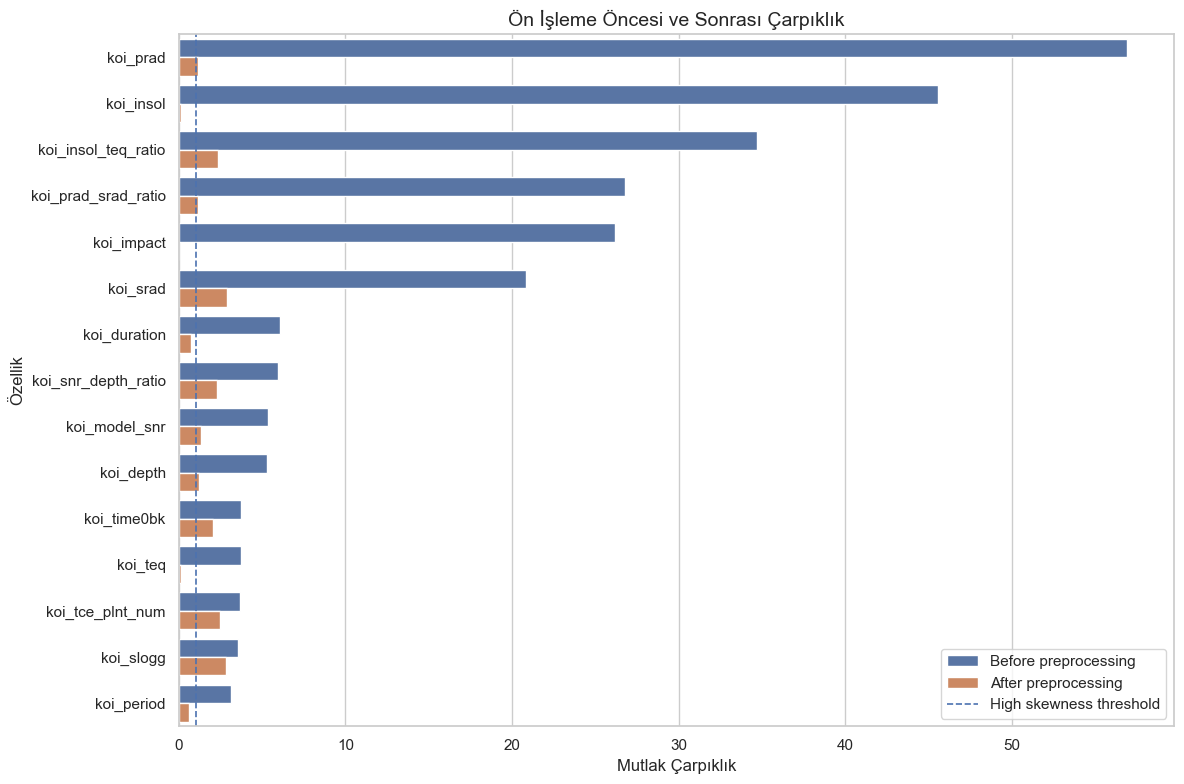

,Before preprocessing,After preprocessing,Reduction (%)
koi_impact,26.194556,0.023270,99.91
koi_insol,45.568982,0.108455,99.76
koi_prad,56.886836,1.175047,97.93
koi_teq,3.698448,0.098344,97.34
koi_prad_srad_ratio,26.763013,1.121497,95.81
koi_insol_teq_ratio,34.719083,2.324586,93.30
koi_duration,6.071626,0.743653,87.75
koi_srad,20.860341,2.873948,86.22
koi_period,3.134611,0.599531,80.87
koi_depth,5.302507,1.217552,77.04


✓ Çarpıklık karşılaştırması tamamlandı.
  → Grafik, log1p dönüşümü ve kırpmanın özellik çarpıklığını nasıl azalttığını gösteriyor.
  → Reduction (%) çarpıklığın ön işleme sonrası ne kadar azaldığını nicelendirir.
  → SMOTE, örnek sayısını değiştirdiği için hariç tutulmuştur.
  → Gerçek ön işleme hala her model pipeline'ı içinde gerçekleştirilir.


In [12]:
# === 4.1 Ön İşleme Önizlemesi: Ön işleme öncesi ve sonrası çarpıklık ===
# Bu önizleme yalnızca görselleştirme amaçlıdır.
# Gerçek ön işleme her model pipeline'ı içinde uygulanmaya devam eder.

preprocessing_steps_no_smote = [
    step for step in build_preprocessing_pipeline(skewed_cols)
    if step[0] != 'smote'
]

preprocessor_preview = Pipeline(preprocessing_steps_no_smote)
X_train_processed = preprocessor_preview.fit_transform(X_train, y_train)

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=X_train.columns,
    index=X_train.index
)

skew_before = X_train[numeric_cols].skew().abs()
skew_after = X_train_processed_df[numeric_cols].skew().abs()

skew_compare = pd.DataFrame({
    'Before preprocessing': skew_before,
    'After preprocessing': skew_after
})

skew_compare['Reduction (%)'] = (
    (skew_compare['Before preprocessing'] - skew_compare['After preprocessing'])
    / skew_compare['Before preprocessing']
    * 100
).round(2)

skew_compare = skew_compare.sort_values('Before preprocessing', ascending=False).head(15)

# Seaborn çubuk grafiği için uzun format
skew_plot_df = skew_compare[['Before preprocessing', 'After preprocessing']].reset_index()
skew_plot_df = skew_plot_df.rename(columns={'index': 'Feature'})
skew_plot_df = skew_plot_df.melt(
    id_vars='Feature',
    var_name='Stage',
    value_name='Absolute Skewness'
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=skew_plot_df,
    x='Absolute Skewness',
    y='Feature',
    hue='Stage'
)

plt.axvline(1, linestyle='--', linewidth=1.2, label='High skewness threshold')
plt.title('Ön İşleme Öncesi ve Sonrası Çarpıklık', fontsize=14)
plt.xlabel('Mutlak Çarpıklık')
plt.ylabel('Özellik')
plt.legend()
plt.tight_layout()
plt.show()

# Display reduction table
display(
    skew_compare[['Before preprocessing', 'After preprocessing', 'Reduction (%)']]
    .sort_values('Reduction (%)', ascending=False)
)

print('✓ Çarpıklık karşılaştırması tamamlandı.')
print('  → Grafik, log1p dönüşümü ve kırpmanın özellik çarpıklığını nasıl azalttığını gösteriyor.')
print('  → Reduction (%) çarpıklığın ön işleme sonrası ne kadar azaldığını nicelendirir.')
print('  → SMOTE, örnek sayısını değiştirdiği için hariç tutulmuştur.')
print('  → Gerçek ön işleme hala her model pipeline\'ı içinde gerçekleştirilir.')

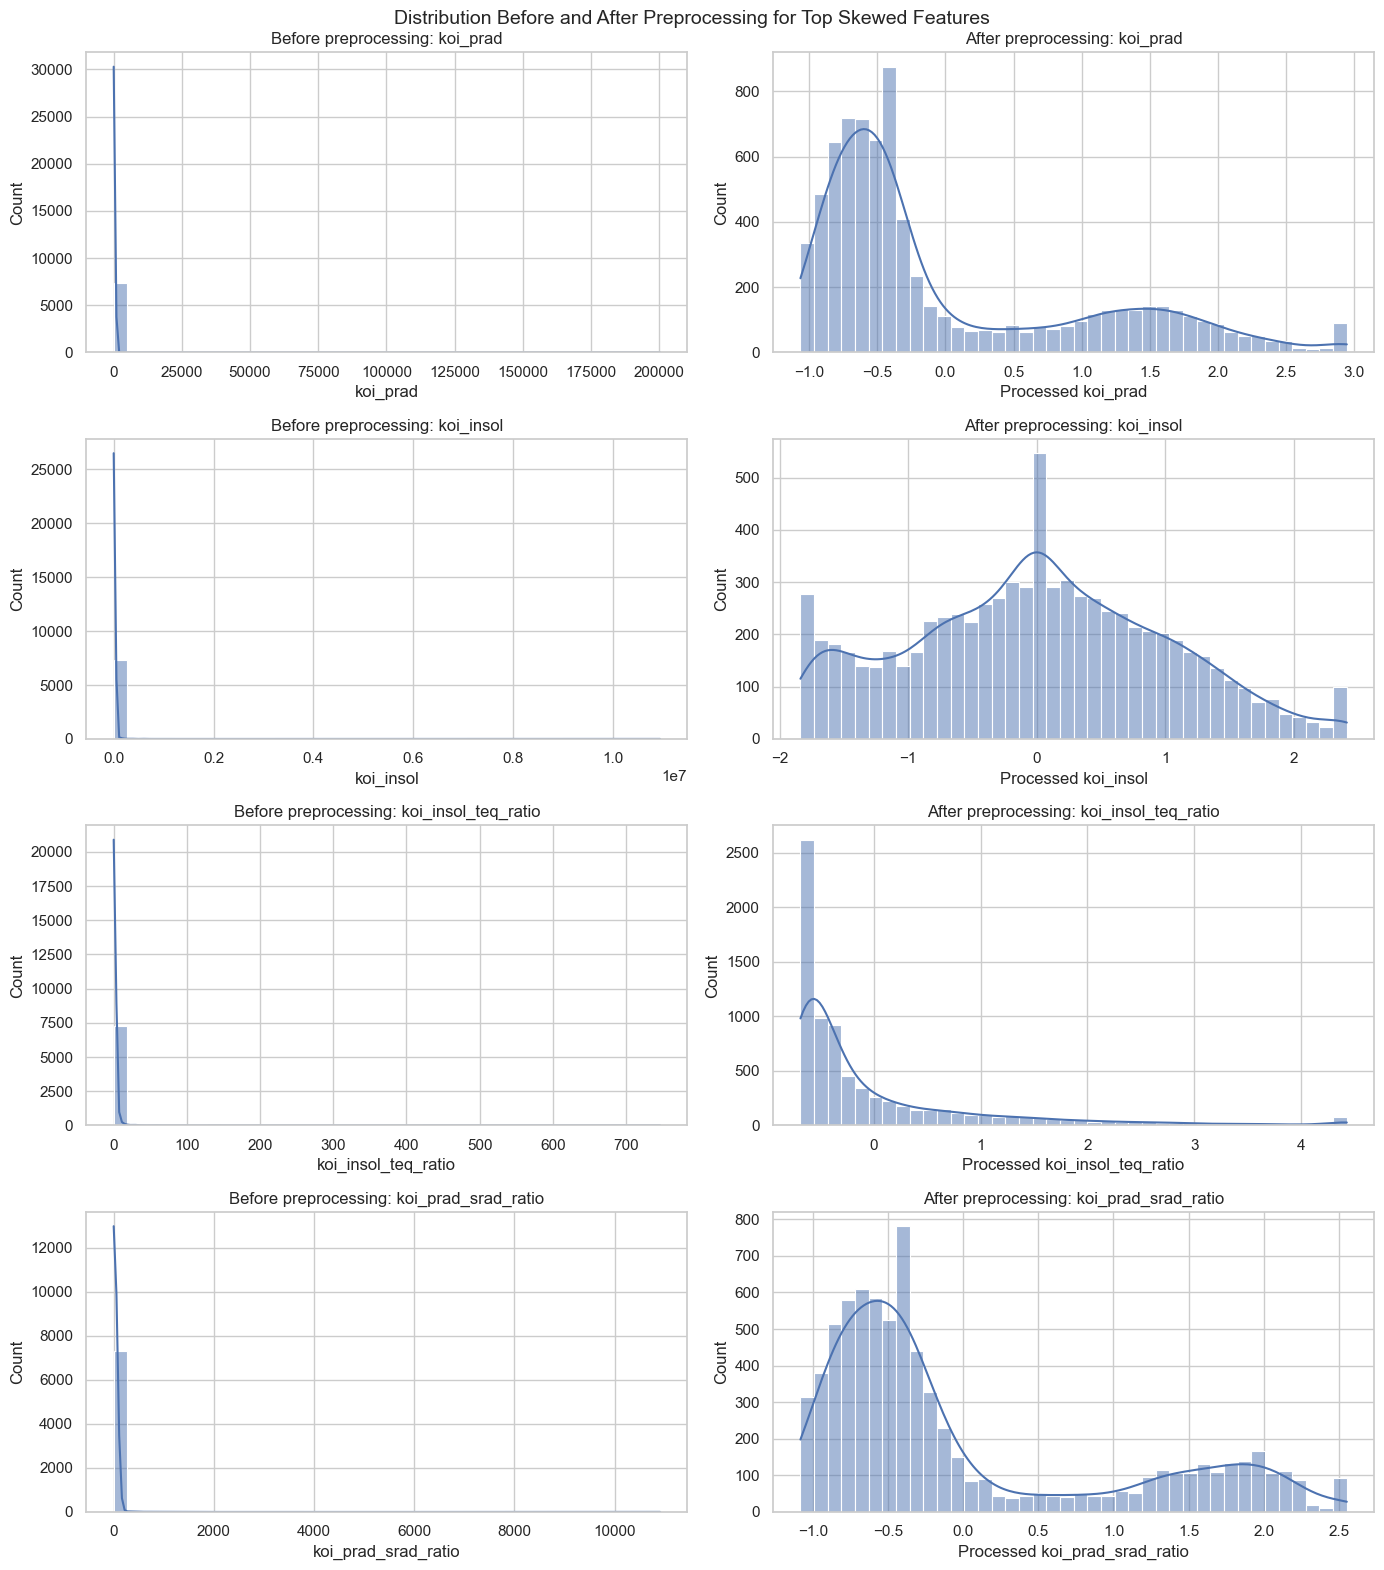

✓ Dağılım karşılaştırması tamamlandı.
  → Histogramlar, ön işlemenin yüksek çarpıklığa sahip özellik dağılımlarının şeklini nasıl değiştirdiğini gösteriyor.
  → Görselleştirmeyi okunabilir tutmak için yalnızca en yüksek 4 çarpık özellik gösterilmiştir.
  → Gerçek ön işleme hala her model pipeline'ı içinde gerçekleştirilir.


In [13]:
# === 4.1 Ön İşleme Önizlemesi: Ön işleme öncesi ve sonrası dağılım ===
# Bu önizleme yalnızca görselleştirme amaçlıdır.
# Gerçek ön işleme her model pipeline'ı içinde uygulanmaya devam eder.

top_skewed_features = skew_compare.index[:4].tolist()

fig, axes = plt.subplots(len(top_skewed_features), 2, figsize=(14, 4 * len(top_skewed_features)))

for i, col in enumerate(top_skewed_features):
    sns.histplot(
        X_train[col].dropna(),
        bins=40,
        kde=True,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Before preprocessing: {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    sns.histplot(
        X_train_processed_df[col].dropna(),
        bins=40,
        kde=True,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'After preprocessing: {col}')
    axes[i, 1].set_xlabel(f'Processed {col}')
    axes[i, 1].set_ylabel('Count')

plt.suptitle('Distribution Before and After Preprocessing for Top Skewed Features', fontsize=14)
plt.tight_layout()
plt.show()

print('✓ Dağılım karşılaştırması tamamlandı.')
print('  → Histogramlar, ön işlemenin yüksek çarpıklığa sahip özellik dağılımlarının şeklini nasıl değiştirdiğini gösteriyor.')
print('  → Görselleştirmeyi okunabilir tutmak için yalnızca en yüksek 4 çarpık özellik gösterilmiştir.')
print('  → Gerçek ön işleme hala her model pipeline\'ı içinde gerçekleştirilir.')

## 5. Temel Modeller

### Değerlendirme Yardımcı Fonksiyonları

In [14]:
# Değerlendirme için yardımcı fonksiyonlar

def evaluate_model(model_name, y_true, y_pred):
    """Modeli değerlendir ve metrikleri döndür"""
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Karışıklık matrisini çiz"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def print_classification_report(y_true, y_pred, class_names):
    """Ayrıntılı sınıflandırma raporunu yazdır"""
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

# Temel ve ayarlanmış sonuçları sakla
baseline_results = []
tuned_results = []

print('Baseline modellerini eğitmeye hazır')

Baseline modellerini eğitmeye hazır


### 5.1 Lojistik Regresyon — Temel Model

BASELINE: Logistic Regression

Eğitim ve tahmin süresi: 0.20 saniye

Sınıflandırma Raporu:
                precision    recall  f1-score   support

     CANDIDATE       0.47      0.74      0.58       396
     CONFIRMED       0.74      0.78      0.76       549
FALSE POSITIVE       0.90      0.66      0.76       968

      accuracy                           0.71      1913
     macro avg       0.70      0.73      0.70      1913
  weighted avg       0.76      0.71      0.72      1913



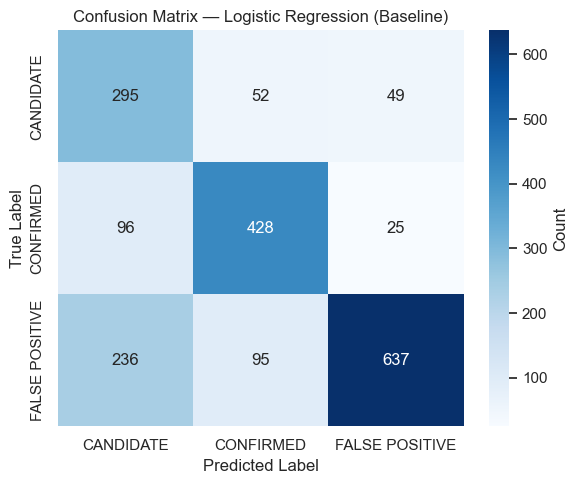

✓ Baseline model sonuçları kaydedildi


In [15]:
# Lojistik Regresyon temel modelini eğit ve değerlendir
print('=' * 60)
print('BASELINE: Logistic Regression')
print('=' * 60)

lr_baseline = Pipeline(
    build_preprocessing_pipeline(skewed_cols) +
    [('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))]
)

start_time = time.time()

lr_baseline.fit(X_train, y_train)
y_pred_lr = lr_baseline.predict(X_test)

elapsed_time = time.time() - start_time

print(f'\nEğitim ve tahmin süresi: {elapsed_time:.2f} saniye')

print('\nSınıflandırma Raporu:')
print_classification_report(y_test, y_pred_lr, le.classes_)

plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression (Baseline)', le.classes_)

baseline_results.append(evaluate_model('Logistic Regression (Baseline)', y_test, y_pred_lr))
print('✓ Baseline model sonuçları kaydedildi')

### 5.2 Karar Ağacı — Temel Model

BASELINE: Decision Tree

Eğitim ve tahmin süresi: 0.33 saniye

Sınıflandırma Raporu:
                precision    recall  f1-score   support

     CANDIDATE       0.42      0.49      0.45       396
     CONFIRMED       0.75      0.69      0.72       549
FALSE POSITIVE       0.77      0.75      0.76       968

      accuracy                           0.68      1913
     macro avg       0.65      0.65      0.65      1913
  weighted avg       0.69      0.68      0.69      1913



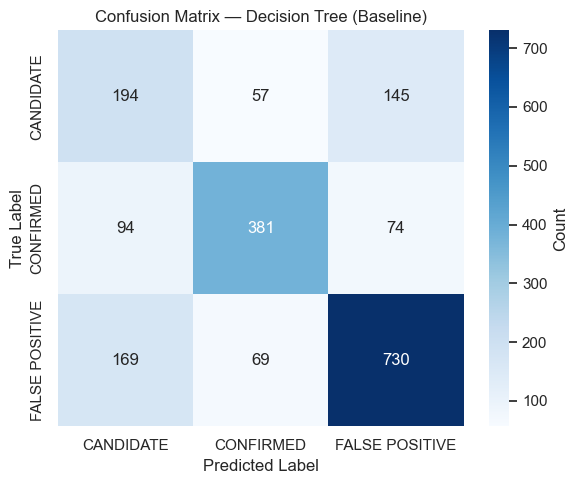

✓ Baseline results stored


In [16]:
# Karar Ağacı temel modelini eğit ve değerlendir
print('=' * 60)
print('BASELINE: Decision Tree')
print('=' * 60)

dt_baseline = Pipeline(
    build_preprocessing_pipeline(skewed_cols) +
    [('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))]
)

start_time = time.time()

dt_baseline.fit(X_train, y_train)
y_pred_dt = dt_baseline.predict(X_test)

elapsed_time = time.time() - start_time
print(f'\nEğitim ve tahmin süresi: {elapsed_time:.2f} saniye')

print('\nSınıflandırma Raporu:')
print_classification_report(y_test, y_pred_dt, le.classes_)

plot_confusion_matrix(y_test, y_pred_dt, 'Decision Tree (Baseline)', le.classes_)

baseline_results.append(evaluate_model('Decision Tree (Baseline)', y_test, y_pred_dt))
print('✓ Baseline results stored')

### 5.3 Rastgele Orman — Temel Model

BASELINE: Random Forest

Eğitim ve tahmin süresi: 0.78 saniye

Sınıflandırma Raporu:
                precision    recall  f1-score   support

     CANDIDATE       0.52      0.65      0.58       396
     CONFIRMED       0.81      0.82      0.82       549
FALSE POSITIVE       0.87      0.77      0.82       968

      accuracy                           0.76      1913
     macro avg       0.73      0.75      0.74      1913
  weighted avg       0.78      0.76      0.77      1913



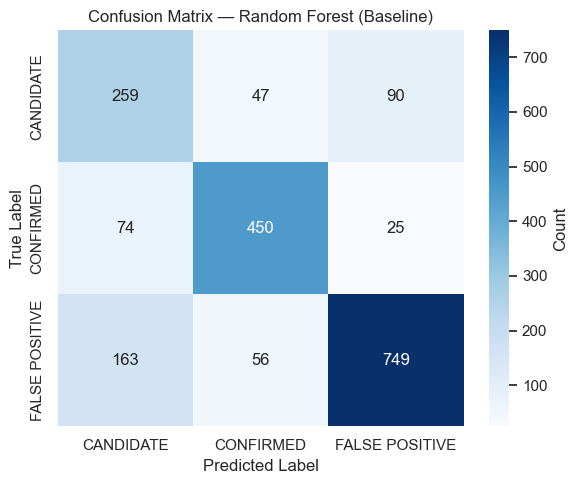

✓ Baseline results stored


In [17]:
# Rastgele Orman temel modelini eğit ve değerlendir
print('=' * 60)
print('BASELINE: Random Forest')
print('=' * 60)

# DEBUG_MODE'a göre koşullu n_estimators
rf_n_estimators = 50 if DEBUG_MODE else 100

rf_baseline = Pipeline(
    build_preprocessing_pipeline(skewed_cols) +
    [('model', RandomForestClassifier(
        n_estimators=rf_n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced'
    ))]
)

start_time = time.time()

rf_baseline.fit(X_train, y_train)
y_pred_rf = rf_baseline.predict(X_test)

elapsed_time = time.time() - start_time
print(f'\nEğitim ve tahmin süresi: {elapsed_time:.2f} saniye')

print('\nSınıflandırma Raporu:')
print_classification_report(y_test, y_pred_rf, le.classes_)

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest (Baseline)', le.classes_)

baseline_results.append(evaluate_model('Random Forest (Baseline)', y_test, y_pred_rf))
print('✓ Baseline results stored')

### 5.4 XGBoost — Temel Model

BASELINE: XGBoost

Eğitim ve tahmin süresi: 0.54 saniye

Sınıflandırma Raporu:
                precision    recall  f1-score   support

     CANDIDATE       0.54      0.73      0.62       396
     CONFIRMED       0.81      0.84      0.83       549
FALSE POSITIVE       0.90      0.75      0.82       968

      accuracy                           0.77      1913
     macro avg       0.75      0.78      0.76      1913
  weighted avg       0.80      0.77      0.78      1913



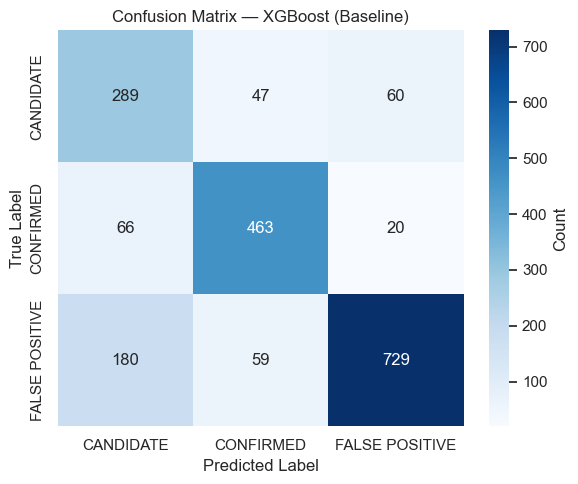

✓ Baseline model sonuçları kaydedildi


In [18]:
if XGBOOST_AVAILABLE:
    print('=' * 60)
    print('BASELINE: XGBoost')
    print('=' * 60)

    # DEBUG_MODE'a göre koşullu n_estimators
    xgb_n_estimators = 50 if DEBUG_MODE else 100

    xgb_baseline = Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', XGBClassifier(
            objective='multi:softprob',
            num_class=len(le.classes_),
            n_estimators=xgb_n_estimators,
            learning_rate=0.1,
            max_depth=5,
            random_state=RANDOM_STATE,
            eval_metric='mlogloss',
            verbosity=0
        ))]
    )

    start_time = time.time()

    xgb_baseline.fit(X_train, y_train)
    y_pred_xgb = xgb_baseline.predict(X_test)

    elapsed_time = time.time() - start_time
    print(f'\nEğitim ve tahmin süresi: {elapsed_time:.2f} saniye')

    print('\nSınıflandırma Raporu:')
    print_classification_report(y_test, y_pred_xgb, le.classes_)

    plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost (Baseline)', le.classes_)

    baseline_results.append(evaluate_model('XGBoost (Baseline)', y_test, y_pred_xgb))
    print('✓ Baseline model sonuçları kaydedildi')

else:
    print('⚠️ XGBoost mevcut değil. XGBoost temel modelini atlıyoruz.')
    xgb_baseline = None

### 5.5 SVM RBF — Temel Model

BASELINE: SVM (RBF kernel)

Eğitim ve tahmin süresi: 1.97 saniye

Sınıflandırma Raporu:
                precision    recall  f1-score   support

     CANDIDATE       0.47      0.74      0.58       396
     CONFIRMED       0.82      0.80      0.81       549
FALSE POSITIVE       0.90      0.71      0.79       968

      accuracy                           0.74      1913
     macro avg       0.73      0.75      0.73      1913
  weighted avg       0.79      0.74      0.75      1913



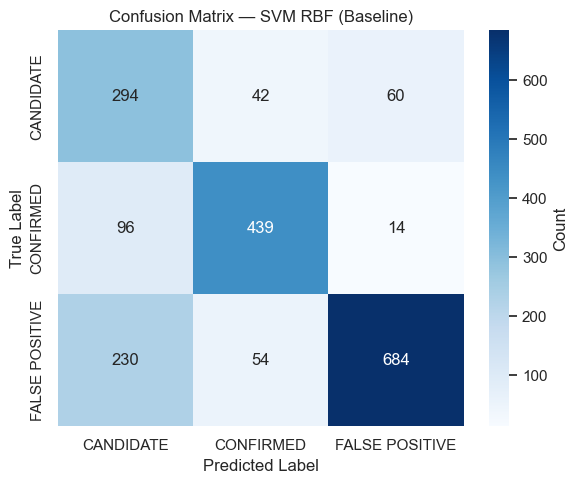

✓ Baseline model sonuçları kaydedildi


In [19]:
# SVM (RBF çekirdek) temel modelini eğit ve değerlendir
print('=' * 60)
print('BASELINE: SVM (RBF kernel)')
print('=' * 60)

svm_baseline = Pipeline(
    build_preprocessing_pipeline(skewed_cols) +
    [('model', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))]
)

start_time = time.time()

svm_baseline.fit(X_train, y_train)
y_pred_svm = svm_baseline.predict(X_test)

elapsed_time = time.time() - start_time
print(f'\nEğitim ve tahmin süresi: {elapsed_time:.2f} saniye')

print('\nSınıflandırma Raporu:')
print_classification_report(y_test, y_pred_svm, le.classes_)

plot_confusion_matrix(y_test, y_pred_svm, 'SVM RBF (Baseline)', le.classes_)

baseline_results.append(evaluate_model('SVM RBF (Baseline)', y_test, y_pred_svm))
print('✓ Baseline model sonuçları kaydedildi')

### 5.5 Yığımlama Sınıflandırıcısı


BASELINE: Stacking Classifier

Eğitim ve tahmin süresi: 20.95 saniye

Sınıflandırma Raporu:
                precision    recall  f1-score   support

     CANDIDATE       0.50      0.74      0.60       396
     CONFIRMED       0.84      0.82      0.83       549
FALSE POSITIVE       0.90      0.74      0.81       968

      accuracy                           0.76      1913
     macro avg       0.75      0.77      0.75      1913
  weighted avg       0.80      0.76      0.77      1913



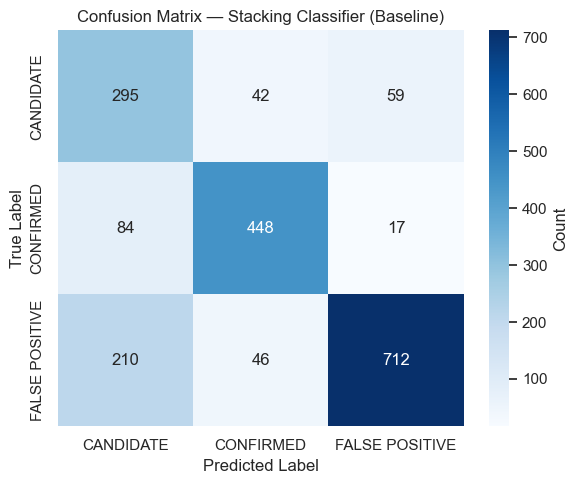

✓ Baseline stacking sonuçları kaydedildi


In [20]:
# Yığımlama (Stacking) temel sınıflandırıcısını oluştur ve değerlendir
print('\n' + '=' * 60)
print('BASELINE: Stacking Classifier')
print('=' * 60)

# Yığımlama için temel tahmin ediciler
stack_estimators = []

if XGBOOST_AVAILABLE:
    stack_estimators.append((
        'xgb',
        Pipeline(
            build_preprocessing_pipeline(skewed_cols) +
            [('model', XGBClassifier(
                objective='multi:softprob',
                num_class=len(le.classes_),
                n_estimators=50 if DEBUG_MODE else 100,
                learning_rate=0.1,
                max_depth=5,
                random_state=RANDOM_STATE,
                eval_metric='mlogloss',
                verbosity=0
            ))]
        )
    ))
else:
    print('⚠️ XGBoost mevcut değil - XGBoost temel modelini atlıyoruz.')

stack_estimators.append((
    'rf',
    Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', RandomForestClassifier(
            n_estimators=50 if DEBUG_MODE else 100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced'
        ))]
    )
))

stack_estimators.append((
    'svm',
    Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE
        ))]
    )
))

if len(stack_estimators) >= 2:
    stacking_baseline = StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        cv=2 if DEBUG_MODE else 5,
        n_jobs=-1
    )

    start_time = time.time()

    stacking_baseline.fit(X_train, y_train)
    y_pred_stack_baseline = stacking_baseline.predict(X_test)

    elapsed_time = time.time() - start_time
    print(f'\nEğitim ve tahmin süresi: {elapsed_time:.2f} saniye')

    print('\nSınıflandırma Raporu:')
    print_classification_report(y_test, y_pred_stack_baseline, le.classes_)

    plot_confusion_matrix(
        y_test,
        y_pred_stack_baseline,
        'Stacking Classifier (Baseline)',
        le.classes_
    )

    baseline_results.append(
        evaluate_model(
            'Stacking Classifier (Baseline)',
            y_test,
            y_pred_stack_baseline
        )
    )

    print('✓ Baseline stacking sonuçları kaydedildi')

else:
    print('⚠️ Yeterli temel tahmin edici mevcut değil - yığımlama modeli oluşturulamıyor')

## 6. Temel Model Karşılaştırması

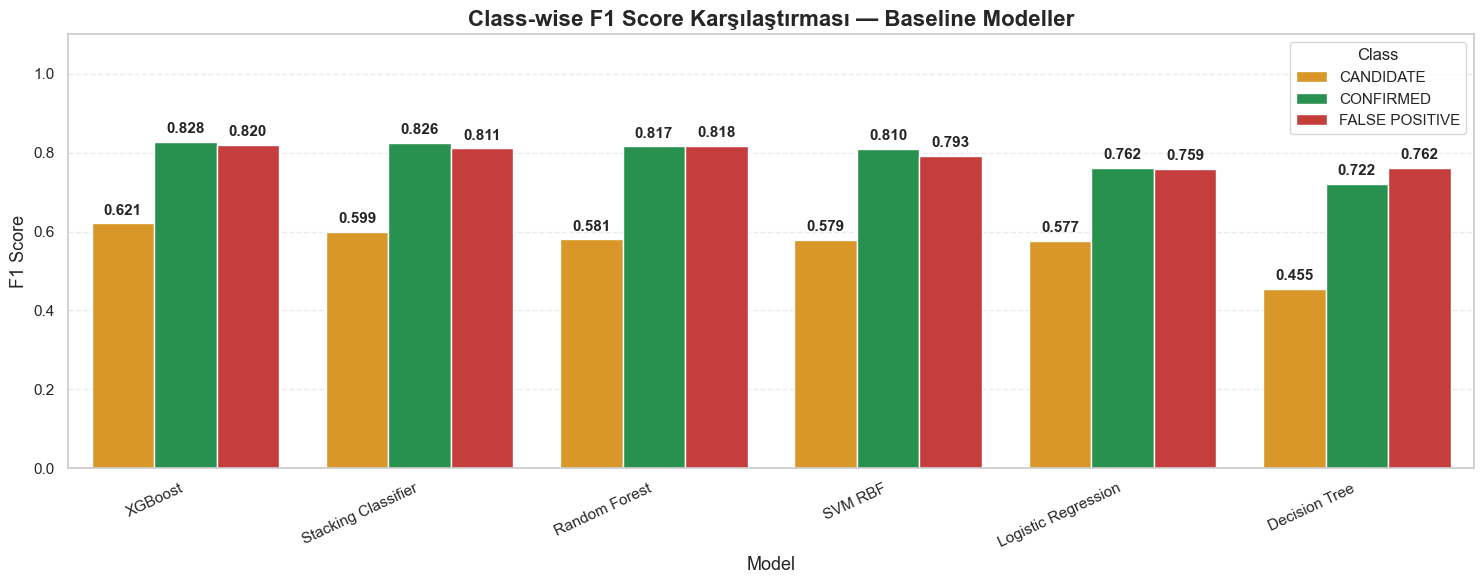

In [21]:
# === Temel modeller için sınıf bazında F1 karşılaştırması ===

baseline_predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM RBF': y_pred_svm
}

if XGBOOST_AVAILABLE and 'y_pred_xgb' in globals():
    baseline_predictions['XGBoost'] = y_pred_xgb

if 'y_pred_stack_baseline' in globals():
    baseline_predictions['Stacking Classifier'] = y_pred_stack_baseline
else:
    print('⚠️ Stacking başlangıç (baseline) modeli tahminleri bulunamadı. Önce Stacking başlangıç (baseline) hücresini çalıştırın.')

class_f1_rows = []

for model_name, y_pred in baseline_predictions.items():
    f1_per_class = f1_score(
        y_test,
        y_pred,
        average=None,
        labels=np.arange(len(le.classes_)),
        zero_division=0
    )
    
    for class_name, f1_val in zip(CLASS_ORDER, f1_per_class):
        class_f1_rows.append({
            'Model': model_name,
            'Class': class_name,
            'F1 Score': f1_val
        })

class_f1_df = pd.DataFrame(class_f1_rows)

# Gerekirse temiz baseline_df'yi yeniden oluştur
baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.drop_duplicates(subset='Model', keep='last')
baseline_df = baseline_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

# Temizlenmiş baseline_df'den model sırasını belirle
model_order = (
    baseline_df['Model']
    .str.replace(' \\(Baseline\\)', '', regex=True)
    .tolist()
)

# Yalnızca class_f1_df'de gerçekten var olan modelleri tut
model_order = [m for m in model_order if m in class_f1_df['Model'].unique()]

plt.figure(figsize=(15, 6))

ax = sns.barplot(
    data=class_f1_df,
    x='Model',
    y='F1 Score',
    hue='Class',
    order=model_order,
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=4,
        fontsize=11,
        fontweight='bold'
    )

plt.title('Class-wise F1 Score Karşılaştırması — Baseline Modeller', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('F1 Score', fontsize=13)
plt.ylim(0, 1.10)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Class', title_fontsize=12, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Hiperparametre Optimizasyonu

In [22]:
# Ortak çapraz doğrulama stratejisini tanımla
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print('Cross-Validation Stratejisi: StratifiedKFold')
print(f'  - Kat sayısı: {CV_SPLITS}')
print(f'  - Shuffle: True')
print(f'  - Random state: {RANDOM_STATE}')
print('\nSkorlama metric: f1_macro')
print('\nNot: X_test hiperparametre ayarlama sırasında KULLANILMAZ')
print('      Ayarlanan modeller, hiperparametre ayarlama sonrasında ayrılmış X_test üzerinde değerlendirilir.')

Cross-Validation Stratejisi: StratifiedKFold
  - Kat sayısı: 5
  - Shuffle: True
  - Random state: 42

Skorlama metric: f1_macro

Not: X_test hiperparametre ayarlama sırasında KULLANILMAZ
      Ayarlanan modeller, hiperparametre ayarlama sonrasında ayrılmış X_test üzerinde değerlendirilir.


### 7.1 Lojistik Regresyon — GridSearchCV


TUNING: Logistic Regression (GridSearchCV)
Fitting 5 folds for each of 83 candidates, totalling 415 fits

Tuning time: 44.17 seconds

Best parameters:
  - C: 3
  - l1_ratio: 0.1
  - penalty: elasticnet
  - solver: saga
Best CV F1 (macro): 0.6867
Test Set Macro F1: 0.6982
Gap (CV - Test): -0.0115

Test Set Sınıflandırma Raporu:
                precision    recall  f1-score   support

     CANDIDATE       0.47      0.74      0.58       396
     CONFIRMED       0.75      0.78      0.76       549
FALSE POSITIVE       0.89      0.66      0.76       968

      accuracy                           0.71      1913
     macro avg       0.70      0.73      0.70      1913
  weighted avg       0.76      0.71      0.72      1913



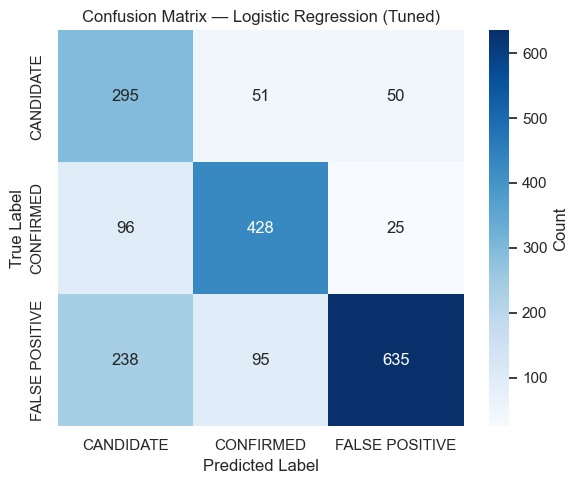

✓ Tuned sonuçları kaydedildi


In [23]:
# Lojistik Regresyon için GridSearchCV ile hiperparametre optimizasyonu yap
print('\n' + '=' * 60)
print('TUNING: Logistic Regression (GridSearchCV)')
print('=' * 60)

# DEBUG_MODE'a göre koşullu param_grid
if DEBUG_MODE:
    lr_param_grid = {
        'model__C': [0.01],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs'],
    }
else:
    lr_param_grid = [
        {
            'model__C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs', 'liblinear'],
        },

        {
            'model__C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
            'model__penalty': ['l1'],
            'model__solver': ['liblinear'],
        },
        {
            'model__C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
            'model__penalty': ['elasticnet'],
            'model__solver': ['saga'],
            'model__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
        }

    ]

lr_search = GridSearchCV(
    estimator=Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE))]
    ),
    param_grid=lr_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()

lr_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\nTuning time: {elapsed_time:.2f} seconds')

print('\nBest parameters:')
for param, value in lr_search.best_params_.items():
    clean_param = param.replace('model__', '')
    print(f'  - {clean_param}: {value}')
print(f'Best CV F1 (macro): {lr_search.best_score_:.4f}')

# Test seti üzerinde değerlendir
y_pred_lr_tuned = lr_search.best_estimator_.predict(X_test)
test_f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned, average='macro', zero_division=0)

# CV - Test karşılaştırması
print(f'Test Set Macro F1: {test_f1_lr_tuned:.4f}')
cv_test_gap = lr_search.best_score_ - test_f1_lr_tuned
print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

if abs(cv_test_gap) > 0.03:
    print(f'⚠️ UYARI: Büyük bir fark tespit edildi (>{0.03:.2f}) — olası dengesizlik veya aşırı uyum')

print('\nTest Set Sınıflandırma Raporu:')
print_classification_report(y_test, y_pred_lr_tuned, le.classes_)

plot_confusion_matrix(y_test, y_pred_lr_tuned, 'Logistic Regression (Tuned)', le.classes_)

tuned_results.append(evaluate_model('Logistic Regression (Tuned)', y_test, y_pred_lr_tuned))
print('✓ Tuned sonuçları kaydedildi')

### 7.2 Karar Ağacı — GridSearchCV


TUNING: Decision Tree (GridSearchCV)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Tuning time: 21.97 seconds

Best parameters:
  - criterion: gini
  - max_depth: 10
  - min_samples_leaf: 20
  - min_samples_split: 2
Best CV F1 (macro): 0.7137
Test Set Macro F1: 0.7098
Gap (CV - Test): +0.0039

Test Set Sınıflandırma Raporu:
                precision    recall  f1-score   support

     CANDIDATE       0.48      0.65      0.55       396
     CONFIRMED       0.77      0.82      0.79       549
FALSE POSITIVE       0.87      0.71      0.78       968

      accuracy                           0.73      1913
     macro avg       0.71      0.73      0.71      1913
  weighted avg       0.76      0.73      0.74      1913



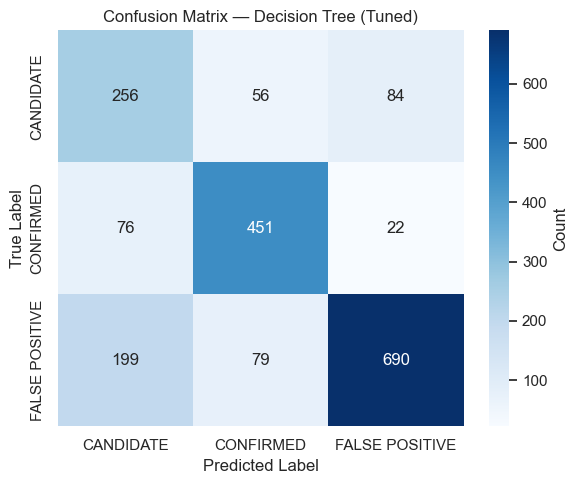

✓ Tuned sonuçları kaydedildi


In [24]:
# Karar Ağacı için GridSearchCV ile hiperparametre optimizasyonu yap
print('\n' + '=' * 60)
print('TUNING: Decision Tree (GridSearchCV)')
print('=' * 60)

# DEBUG_MODE'a göre koşullu param_grid
if DEBUG_MODE:
    dt_param_grid = {
        'model__max_depth': [5],
        'model__min_samples_split': [2],
        'model__min_samples_leaf': [1],
        'model__criterion': ['gini'],
    }
else:
    dt_param_grid = {
        'model__max_depth': [5, 8, 10, 12, 15],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [5, 10, 15, 20],
        'model__criterion': ['gini', 'entropy'],
    }

dt_search = GridSearchCV(
    estimator=Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))]
    ),
    param_grid=dt_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()

dt_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\nTuning time: {elapsed_time:.2f} seconds')

print('\nBest parameters:')
for param, value in dt_search.best_params_.items():
    clean_param = param.replace('model__', '')
    print(f'  - {clean_param}: {value}')
print(f'Best CV F1 (macro): {dt_search.best_score_:.4f}')

# Test seti üzerinde değerlendir
y_pred_dt_tuned = dt_search.best_estimator_.predict(X_test)
test_f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned, average='macro', zero_division=0)

# CV - Test karşılaştırması
print(f'Test Set Macro F1: {test_f1_dt_tuned:.4f}')
cv_test_gap = dt_search.best_score_ - test_f1_dt_tuned
print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

if abs(cv_test_gap) > 0.03:
    print(f'⚠️ UYARI: Büyük bir fark tespit edildi (>{0.03:.2f}) — olası dengesizlik veya aşırı uyum')

print('\nTest Set Sınıflandırma Raporu:')
print_classification_report(y_test, y_pred_dt_tuned, le.classes_)

plot_confusion_matrix(y_test, y_pred_dt_tuned, 'Decision Tree (Tuned)', le.classes_)

tuned_results.append(evaluate_model('Decision Tree (Tuned)', y_test, y_pred_dt_tuned))
print('✓ Tuned sonuçları kaydedildi')

### 7.3 Rastgele Orman — RandomizedSearchCV


TUNING: Random Forest (RandomizedSearchCV, n_iter=40)
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Tuning time: 376.39 seconds

Best parameters:
  - n_estimators: 800
  - min_samples_split: 10
  - min_samples_leaf: 2
  - max_features: log2
  - max_depth: None
  - bootstrap: False

Best CV F1 (macro): 0.7553
Test Set Macro F1: 0.7399
Gap (CV - Test): +0.0153

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.52      0.64      0.57       396
     CONFIRMED       0.83      0.83      0.83       549
FALSE POSITIVE       0.86      0.78      0.82       968

      accuracy                           0.76      1913
     macro avg       0.74      0.75      0.74      1913
  weighted avg       0.78      0.76      0.77      1913



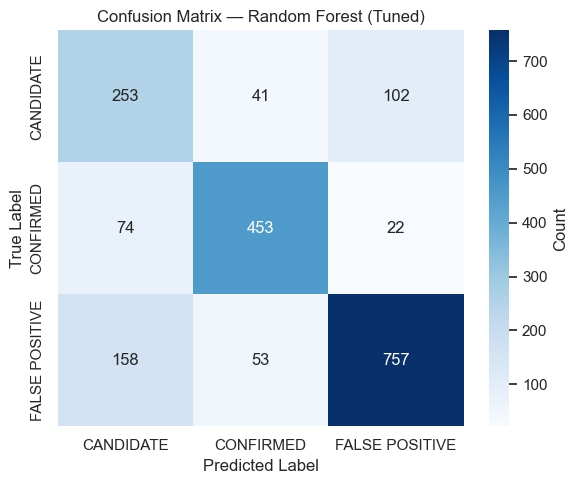

✓ Tuned results stored


In [ ]:
# Rastgele Orman için RandomizedSearchCV ile hiperparametre optimizasyonu yap
print('\n' + '=' * 60)
print('TUNING: Random Forest (RandomizedSearchCV, n_iter=40)')
print('=' * 60)

# DEBUG_MODE'a göre koşullu n_iter ve param_grid
rf_n_iter = 3 if DEBUG_MODE else 40

if DEBUG_MODE:
    rf_param_grid = {
        'model__n_estimators': [50],
        'model__max_depth': [None],
        'model__min_samples_split': [2],
        'model__min_samples_leaf': [1],
        'model__max_features': ['sqrt'],
        'model__bootstrap': [True],
    }
else:
    rf_param_grid = {
        'model__n_estimators': [100, 200, 400, 600, 800],
        'model__max_depth': [None, 5, 10, 20, 30, 50],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'model__max_features': ['sqrt', 'log2'],
        'model__bootstrap': [True, False],
    }

rf_search = RandomizedSearchCV(
    estimator=Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced'
        ))]
    ),
    param_distributions=rf_param_grid,
    n_iter=rf_n_iter,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

start_time = time.time()

rf_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\nTuning time: {elapsed_time:.2f} seconds')

print('\nBest parameters:')
for param, value in rf_search.best_params_.items():
    clean_param = param.replace('model__', '')
    print(f'  - {clean_param}: {value}')

print(f'\nBest CV F1 (macro): {rf_search.best_score_:.4f}')

# Test seti üzerinde değerlendir
y_pred_rf_tuned = rf_search.best_estimator_.predict(X_test)
test_f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='macro', zero_division=0)

# CV - Test karşılaştırması
print(f'Test Set Macro F1: {test_f1_rf_tuned:.4f}')
cv_test_gap = rf_search.best_score_ - test_f1_rf_tuned
print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

if abs(cv_test_gap) > 0.03:
    print(f'⚠️ UYARI: Büyük bir fark tespit edildi (>{0.03:.2f}) — olası dengesizlik veya aşırı uyum')

print('\nTest Set Sınıflandırma Raporu:')
print_classification_report(y_test, y_pred_rf_tuned, le.classes_)

plot_confusion_matrix(y_test, y_pred_rf_tuned, 'Random Forest (Tuned)', le.classes_)

tuned_results.append(evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf_tuned))
print('✓ Tuned sonuçları kaydedildi')

### 7.4 XGBoost — Optuna Optimizasyonu (n_trials=50)


TUNING: XGBoost (Optuna)

Tuning time: 188.59 seconds

Best Optuna CV F1 (macro): 0.7670

Best parameters:
  - n_estimators: 700
  - max_depth: 8
  - learning_rate: 0.12475146219429756
  - subsample: 0.8326739905134763
  - colsample_bytree: 0.6114115017098533
  - gamma: 0.15448232757889319
  - reg_alpha: 2.709082082015443
  - reg_lambda: 5.1194326313194365
  - min_child_weight: 4

Test Set Macro F1: 0.7560
Gap (CV - Test): +0.0110

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.54      0.66      0.59       396
     CONFIRMED       0.84      0.83      0.83       549
FALSE POSITIVE       0.88      0.80      0.84       968

      accuracy                           0.78      1913
     macro avg       0.75      0.76      0.76      1913
  weighted avg       0.80      0.78      0.79      1913



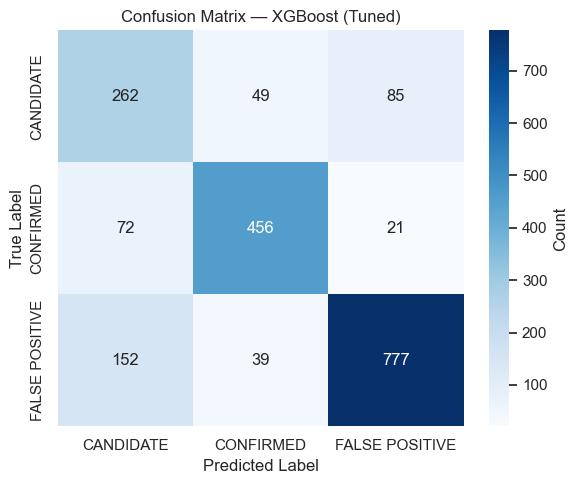

✓ Tuned results stored


In [ ]:
if XGBOOST_AVAILABLE and OPTUNA_AVAILABLE:
    print('\n' + '=' * 60)
    print('TUNING: XGBoost (Optuna)')
    print('=' * 60)

    # 50 zaten yeterlidir; 75, Optuna'ya daha geniş arama uzayını keşfetmesi için daha fazla alan tanır.
    n_trials = 5 if DEBUG_MODE else 75

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_categorical(
                'n_estimators',
                [200, 300, 500, 700, 1000]
            ) if not DEBUG_MODE else 200,

            'max_depth': trial.suggest_int(
                'max_depth',
                2, 10
            ) if not DEBUG_MODE else 2,

            'learning_rate': trial.suggest_float(
                'learning_rate',
                0.005, 0.15,
                log=True
            ) if not DEBUG_MODE else 0.005,

            'subsample': trial.suggest_float(
                'subsample',
                0.6, 1.0
            ) if not DEBUG_MODE else 0.6,

            'colsample_bytree': trial.suggest_float(
                'colsample_bytree',
                0.6, 1.0
            ) if not DEBUG_MODE else 0.6,

            'gamma': trial.suggest_float(
                'gamma',
                0.0, 5.0
            ) if not DEBUG_MODE else 0.0,

            'reg_alpha': trial.suggest_float(
                'reg_alpha',
                0.0, 5.0
            ) if not DEBUG_MODE else 0.0,

            'reg_lambda': trial.suggest_float(
                'reg_lambda',
                0.5, 15.0
            ) if not DEBUG_MODE else 0.5,

            'min_child_weight': trial.suggest_int(
                'min_child_weight',
                1, 10
            ) if not DEBUG_MODE else 1,
        }

        estimator = Pipeline(
            build_preprocessing_pipeline(skewed_cols) +
            [('model', XGBClassifier(
                objective='multi:softprob',
                num_class=len(le.classes_),
                random_state=RANDOM_STATE,
                eval_metric='mlogloss',
                verbosity=0,
                n_jobs=1,  # iç içe paralellikten kaçın; paralelliği cross_val_score yönetir
                **params
            ))]
        )

        scores = cross_val_score(
            estimator,
            X_train,
            y_train,
            scoring='f1_macro',
            cv=cv,
            n_jobs=-1
        )

        return scores.mean()

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)

    start_time = time.time()

    study.optimize(objective, n_trials=n_trials)

    elapsed_time = time.time() - start_time
    print(f'\nTuning time: {elapsed_time:.2f} seconds')

    print(f'\nBest Optuna CV F1 (macro): {study.best_value:.4f}')

    print('\nBest parameters:')
    for param, value in study.best_params.items():
        print(f'  - {param}: {value}')

    best_params = study.best_params.copy()

    xgb_pipeline = Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', XGBClassifier(
            objective='multi:softprob',
            num_class=len(le.classes_),
            random_state=RANDOM_STATE,
            eval_metric='mlogloss',
            verbosity=0,
            n_jobs=1,
            **best_params
        ))]
    )

    xgb_pipeline.fit(X_train, y_train)
    y_pred_xgb_tuned = xgb_pipeline.predict(X_test)

    test_f1_xgb_tuned = f1_score(
        y_test,
        y_pred_xgb_tuned,
        average='macro',
        zero_division=0
    )

    print(f'\nTest Set Macro F1: {test_f1_xgb_tuned:.4f}')
    cv_test_gap = study.best_value - test_f1_xgb_tuned
    print(f'Fark (CV - Test): {cv_test_gap:+.4f}')

    if abs(cv_test_gap) > 0.03:
        print(f'⚠️ UYARI: Büyük bir fark tespit edildi (>{0.03:.2f}) — olası dengesizlik veya aşırı uyum')

    print('\nTest Set Sınıflandırma Raporu:')
    print_classification_report(y_test, y_pred_xgb_tuned, le.classes_)

    plot_confusion_matrix(y_test, y_pred_xgb_tuned, 'XGBoost (Tuned)', le.classes_)

    tuned_results.append(evaluate_model('XGBoost (Tuned)', y_test, y_pred_xgb_tuned))

    xgb_search = SimpleNamespace(
        best_estimator_=xgb_pipeline,
        best_score_=study.best_value,
        best_params_=best_params
    )

    print('✓ Tuned results stored')

elif XGBOOST_AVAILABLE and not OPTUNA_AVAILABLE:
    print('⚠️ Optuna mevcut değil. XGBoost Optuna ayarlamasını atlıyoruz.')
    xgb_search = None

else:
    print('⚠️ XGBoost mevcut değil. XGBoost ayarlamasını atlıyorum.')
    xgb_search = None

### 7.5 SVM RBF — GridSearchCV


TUNING: SVM RBF (GridSearchCV)
Fitting 5 folds for each of 49 candidates, totalling 245 fits



Tuning time: 103.50 seconds

Best parameters:
  - C: 10
  - gamma: auto
  - kernel: rbf

Best CV F1 (macro): 0.7369
Test Set Macro F1: 0.7270
Gap (CV - Test): +0.0098

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.48      0.69      0.56       396
     CONFIRMED       0.82      0.80      0.81       549
FALSE POSITIVE       0.89      0.74      0.81       968

      accuracy                           0.75      1913
     macro avg       0.73      0.74      0.73      1913
  weighted avg       0.78      0.75      0.76      1913



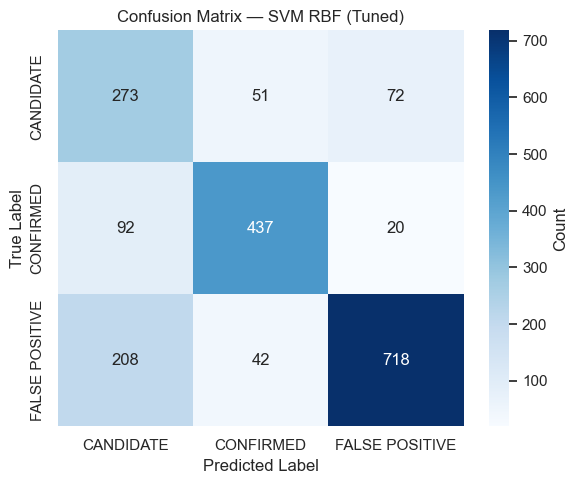

✓ Tuned results stored


In [ ]:
# SVM RBF için GridSearchCV ile hiperparametre optimizasyonu yap
print('\n' + '=' * 60)
print('TUNING: SVM RBF (GridSearchCV)')
print('=' * 60)

# DEBUG_MODE'a göre koşullu param_grid
if DEBUG_MODE:
    svm_param_grid = {
        'model__C': [0.01],
        'model__gamma': ['scale'],
        'model__kernel': ['rbf'],
    }
else:
    svm_param_grid = {
        'model__C': [0.01, 0.1, 1, 3, 10, 30, 100],
        'model__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1],
        'model__kernel': ['rbf'],
    }

svm_search = GridSearchCV(
    estimator=Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', SVC(
            kernel='rbf',
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))]
    ),
    param_grid=svm_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()

svm_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\nTuning time: {elapsed_time:.2f} seconds')

print('\nBest parameters:')
for param, value in svm_search.best_params_.items():
    clean_param = param.replace('model__', '')
    print(f'  - {clean_param}: {value}')

print(f'\nBest CV F1 (macro): {svm_search.best_score_:.4f}')

# Test seti üzerinde değerlendir
y_pred_svm_tuned = svm_search.best_estimator_.predict(X_test)
test_f1_svm_tuned = f1_score(
    y_test,
    y_pred_svm_tuned,
    average='macro',
    zero_division=0
)

# CV - Test karşılaştırması
print(f'Test Set Macro F1: {test_f1_svm_tuned:.4f}')
cv_test_gap = svm_search.best_score_ - test_f1_svm_tuned
print(f'Fark (CV - Test): {cv_test_gap:+.4f}')

if abs(cv_test_gap) > 0.03:
    print(f'⚠️ UYARI: Büyük bir fark tespit edildi (>{0.03:.2f}) — olası dengesizlik veya aşırı uyum')

print('\nTest Set Sınıflandırma Raporu:')
print_classification_report(y_test, y_pred_svm_tuned, le.classes_)

plot_confusion_matrix(y_test, y_pred_svm_tuned, 'SVM RBF (Tuned)', le.classes_)

tuned_results.append(evaluate_model('SVM RBF (Tuned)', y_test, y_pred_svm_tuned))
print('✓ Tuned sonuçları kaydedildi')

### 7.6 Yığımlama Sınıflandırıcısı (XGBoost + Rastgele Orman + SVM)


STACKING: XGB + RF + SVM — LogisticRegression final estimator
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Tuning time: 364.08 seconds

Best stacking parameters:
  - final_estimator__C: 10
  - passthrough: False

Best stacking CV F1 (macro): 0.7533
Test Set Macro F1: 0.7468
Gap (CV - Test): +0.0065

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.57      0.56      0.56       396
     CONFIRMED       0.84      0.83      0.84       549
FALSE POSITIVE       0.84      0.85      0.84       968

      accuracy                           0.78      1913
     macro avg       0.75      0.75      0.75      1913
  weighted avg       0.78      0.78      0.78      1913



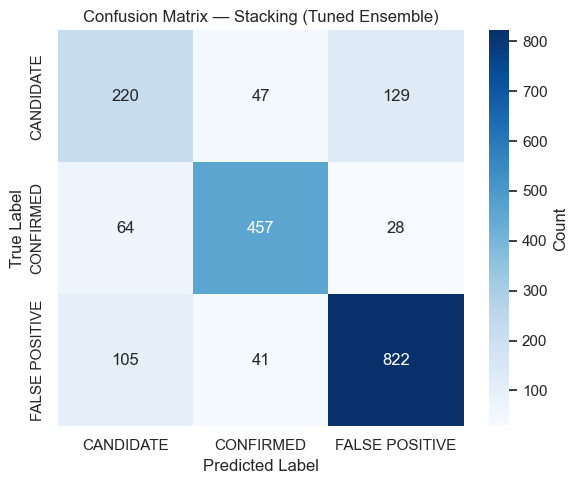

✓ Tuned stacking ensemble results stored


In [ ]:
# Ayarlanmış XGBoost, RF ve SVM modellerini yığımlayarak GridSearchCV ile optimize et
print('\n' + '=' * 60)
print('STACKING: XGB + RF + SVM — LogisticRegression final estimator')
print('=' * 60)

# Ayarlama adımlarından gelen temel tahmin edicilerin mevcut olduğunu doğrula
estimators = []

if XGBOOST_AVAILABLE and 'xgb_pipeline' in globals() and xgb_pipeline is not None:
    estimators.append(('xgb', xgb_pipeline))
else:
    print('⚠️ XGBoost tuned modeli hazır değil — stacking içinde XGB atlanıyor')

if 'rf_search' in globals() and rf_search is not None:
    estimators.append(('rf', rf_search.best_estimator_))
else:
    print('⚠️ RandomForest tuned modeli hazır değil — stacking içinde RF atlanıyor')


if 'svm_search' in globals() and svm_search is not None:
    estimators.append(('svm', svm_search.best_estimator_))
else:
    print('⚠️ SVM tuned modeli hazır değil — stacking içinde SVM atlanıyor')

if len(estimators) >= 2:
    base_stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=2 if DEBUG_MODE else 5,
        n_jobs=-1
    )

    if DEBUG_MODE:
        stack_param_grid = {
            'passthrough': [False],
            'final_estimator__C': [1]
        }
        stack_cv = 2
    else:
        stack_param_grid = {
            'passthrough': [False, True],
            'final_estimator__C': [1, 10]
        }
        stack_cv = 3

    stack_search = GridSearchCV(
        estimator=base_stack,
        param_grid=stack_param_grid,
        scoring='f1_macro',
        cv=stack_cv,
        n_jobs=-1,
        verbose=1
    )

    start_time = time.time()

    stack_search.fit(X_train, y_train)

    elapsed_time = time.time() - start_time
    print(f'\nTuning zamanı: {elapsed_time:.2f} saniye')

    print('\nEn iyi stacking parametreleri:')
    for param, value in stack_search.best_params_.items():
        print(f'  - {param}: {value}')

    print(f'\nEn iyi stacking CV F1 (macro): {stack_search.best_score_:.4f}')

    stacking_model = stack_search.best_estimator_
    y_pred_stack = stacking_model.predict(X_test)

    test_f1_stack = f1_score(y_test, y_pred_stack, average='macro', zero_division=0)
    print(f'Test Set Macro F1: {test_f1_stack:.4f}')

    cv_test_gap = stack_search.best_score_ - test_f1_stack
    print(f'Fark (CV - Test): {cv_test_gap:+.4f}')

    if abs(cv_test_gap) > 0.03:
        print(f'⚠️ UYARI: Büyük bir fark tespit edildi (>{0.03:.2f}) — olası dengesizlik veya aşırı uyum')

    print('\nTest Set Sınıflandırma Raporu:')
    print_classification_report(y_test, y_pred_stack, le.classes_)

    plot_confusion_matrix(y_test, y_pred_stack, 'Stacking (Tuned Ensemble)', le.classes_)

    tuned_results.append(evaluate_model('Stacking (Tuned Ensemble)', y_test, y_pred_stack))

    print('✓ Tuned stacking ensemble sonuçları kaydedildi')

else:
    print('⚠️ Yeterli ayarlanmış temel tahmin edici mevcut değil — stacking modeli oluşturulamıyor')

## 8. Ayarlanmış Model Karşılaştırması

In [ ]:
# === Son Karşılaştırmalardan Önce Temiz Sonuç Tablolarını Oluştur ===

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.drop_duplicates(subset='Model', keep='last')
baseline_df = baseline_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

tuned_df = pd.DataFrame(tuned_results)
tuned_df = tuned_df.drop_duplicates(subset='Model', keep='last')
tuned_df = tuned_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('\n' + '=' * 80)
print('BASELINE MODEL SONUÇLARI')
print('=' * 80)

display(baseline_df.style.format({
    'Accuracy': '{:.4f}',
    'Macro Precision': '{:.4f}',
    'Macro Recall': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Weighted F1': '{:.4f}'
}))

print('\n' + '=' * 80)
print('TUNED MODEL SONUÇLARI')
print('=' * 80)

display(tuned_df.style.format({
    'Accuracy': '{:.4f}',
    'Macro Precision': '{:.4f}',
    'Macro Recall': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Weighted F1': '{:.4f}'
}))

print(f'\nEn iyi baseline model: {baseline_df.iloc[0]["Model"]}')
print(f'En iyi baseline Macro F1: {baseline_df.iloc[0]["Macro F1"]:.4f}')

print(f'\nEn iyi tuned model: {tuned_df.iloc[0]["Model"]}')
print(f'En iyi tuned Macro F1: {tuned_df.iloc[0]["Macro F1"]:.4f}')



BASELINE MODEL RESULTS


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost (Baseline),0.7742,0.7517,0.7754,0.7565,0.7814
1,Stacking Classifier (Baseline),0.7606,0.7467,0.7655,0.7452,0.7713
2,Random Forest (Baseline),0.7622,0.7343,0.7492,0.7384,0.7683
3,SVM RBF (Baseline),0.7407,0.7324,0.7496,0.7271,0.7533
4,Logistic Regression (Baseline),0.7109,0.7036,0.7275,0.6990,0.7219
5,Decision Tree (Baseline),0.6822,0.6484,0.6460,0.6460,0.6866



TUNED MODEL RESULTS


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost (Tuned),0.7815,0.7524,0.7650,0.7560,0.7873
1,Stacking (Tuned Ensemble),0.7836,0.7479,0.7457,0.7468,0.7831
2,Random Forest (Tuned),0.7648,0.7364,0.7487,0.7399,0.7705
3,SVM RBF (Tuned),0.7465,0.7291,0.7424,0.7270,0.7578
4,Decision Tree (Tuned),0.7303,0.7062,0.7269,0.7098,0.7383
5,Logistic Regression (Tuned),0.7099,0.7030,0.7268,0.6982,0.7209



Best baseline model: XGBoost (Baseline)
Best baseline Macro F1: 0.7565

Best tuned model: XGBoost (Tuned)
Best tuned Macro F1: 0.7560


In [ ]:
# === Temel Model - Ayarlanmış Model Karşılaştırması ===

# Model isimlerini karşılaştırma için normalize et
def normalize_model_name(name):
    name = name.replace(' (Baseline)', '')
    name = name.replace(' (Tuned)', '')
    name = name.replace(' (Tuned Ensemble)', '')
    name = name.replace('Stacking Classifier', 'Stacking')
    return name

baseline_clean = baseline_df.copy()
tuned_clean = tuned_df.copy()

baseline_clean = baseline_clean.drop_duplicates(subset='Model', keep='last')
tuned_clean = tuned_clean.drop_duplicates(subset='Model', keep='last')

baseline_clean['Base Model'] = baseline_clean['Model'].apply(normalize_model_name)
tuned_clean['Base Model'] = tuned_clean['Model'].apply(normalize_model_name)

comparison_df = baseline_clean.merge(
    tuned_clean,
    on='Base Model',
    suffixes=(' Baseline', ' Tuned')
)

comparison_df['Macro F1 Improvement'] = (
    comparison_df['Macro F1 Tuned'] - comparison_df['Macro F1 Baseline']
)

comparison_df = comparison_df.sort_values('Macro F1 Tuned', ascending=False).reset_index(drop=True)

print('\n' + '=' * 80)
print('BASELINE VS TUNED MODEL KARŞILAŞTIRMASI')
print('=' * 80)

display(comparison_df[[
    'Base Model',
    'Macro F1 Baseline',
    'Macro F1 Tuned',
    'Macro F1 Improvement',
    'Accuracy Baseline',
    'Accuracy Tuned',
    'Weighted F1 Baseline',
    'Weighted F1 Tuned'
]].style.format({
    'Macro F1 Baseline': '{:.4f}',
    'Macro F1 Tuned': '{:.4f}',
    'Macro F1 Improvement': '{:+.4f}',
    'Accuracy Baseline': '{:.4f}',
    'Accuracy Tuned': '{:.4f}',
    'Weighted F1 Baseline': '{:.4f}',
    'Weighted F1 Tuned': '{:.4f}'
}))


BASELINE VS TUNED MODEL COMPARISON


,Base Model,Macro F1 Baseline,Macro F1 Tuned,Macro F1 Improvement,Accuracy Baseline,Accuracy Tuned,Weighted F1 Baseline,Weighted F1 Tuned
0,XGBoost,0.7565,0.7560,-0.0005,0.7742,0.7815,0.7814,0.7873
1,Stacking,0.7452,0.7468,+0.0015,0.7606,0.7836,0.7713,0.7831
2,Random Forest,0.7384,0.7399,+0.0016,0.7622,0.7648,0.7683,0.7705
3,SVM RBF,0.7271,0.7270,-0.0001,0.7407,0.7465,0.7533,0.7578
4,Decision Tree,0.6460,0.7098,+0.0638,0.6822,0.7303,0.6866,0.7383
5,Logistic Regression,0.6990,0.6982,-0.0008,0.7109,0.7099,0.7219,0.7209


### 8.1 Temel Model - Ayarlanmış Model Karşılaştırması

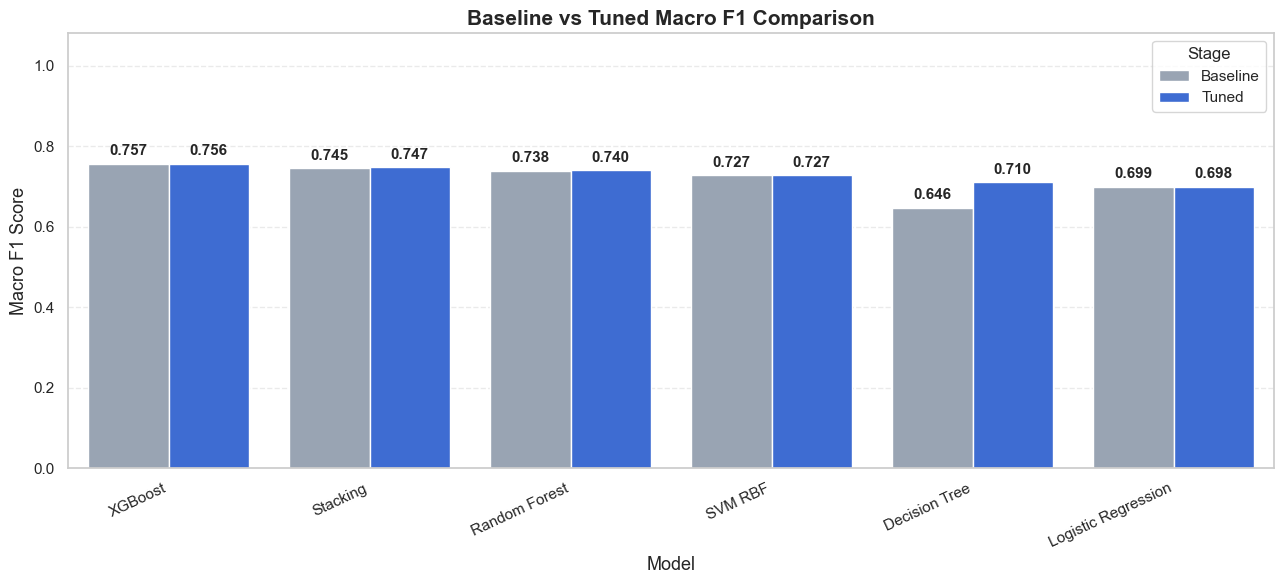

In [ ]:
# === Grafik 1: Temel Model - Ayarlanmış Model Makro F1 ===

plot_df = comparison_df[['Base Model', 'Macro F1 Baseline', 'Macro F1 Tuned']].melt(
    id_vars='Base Model',
    var_name='Stage',
    value_name='Macro F1'
)

plot_df['Stage'] = plot_df['Stage'].replace({
    'Macro F1 Baseline': 'Baseline',
    'Macro F1 Tuned': 'Tuned'
})

plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=plot_df,
    x='Base Model',
    y='Macro F1',
    hue='Stage',
    palette=STAGE_PALETTE
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=4,
        fontsize=11,
        fontweight='bold'
    )

plt.title('Baseline vs Tuned Macro F1 Karşılaştırması', fontsize=15, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('Macro F1 Skoru', fontsize=13)
plt.ylim(0, 1.08)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Stage', title_fontsize=12, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

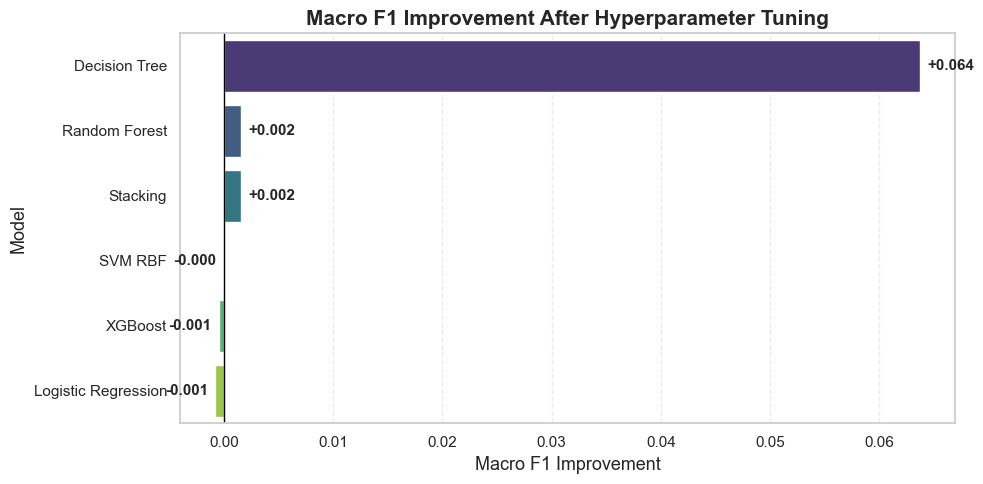

In [ ]:
# === Grafik 2: Ayarlamadan Sonra Makro F1 İyileşmesi ===

improvement_df = comparison_df.sort_values('Macro F1 Improvement', ascending=False)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=improvement_df,
    x='Macro F1 Improvement',
    y='Base Model',
    hue='Base Model',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%+.3f',
        padding=5,
        fontsize=11,
        fontweight='bold'
    )

plt.axvline(0, color='black', linewidth=1)
plt.title('Hiperparametre Optimizasyonu Sonrası Macro F1 İyileşmesi', fontsize=15, fontweight='bold')
plt.xlabel('Macro F1 İyileşmesi', fontsize=13)
plt.ylabel('Model', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 8.2 Model Kararlılığı: CV - Test Makro F1

,Model,CV Macro F1,Test Macro F1,Gap (CV - Test)
0,XGBoost,0.7670,0.7560,+0.0110
1,Stacking,0.7533,0.7468,+0.0065
2,Random Forest,0.7553,0.7399,+0.0153
3,SVM RBF,0.7369,0.7270,+0.0098
4,Decision Tree,0.7137,0.7098,+0.0039
5,Logistic Regression,0.6867,0.6982,-0.0115


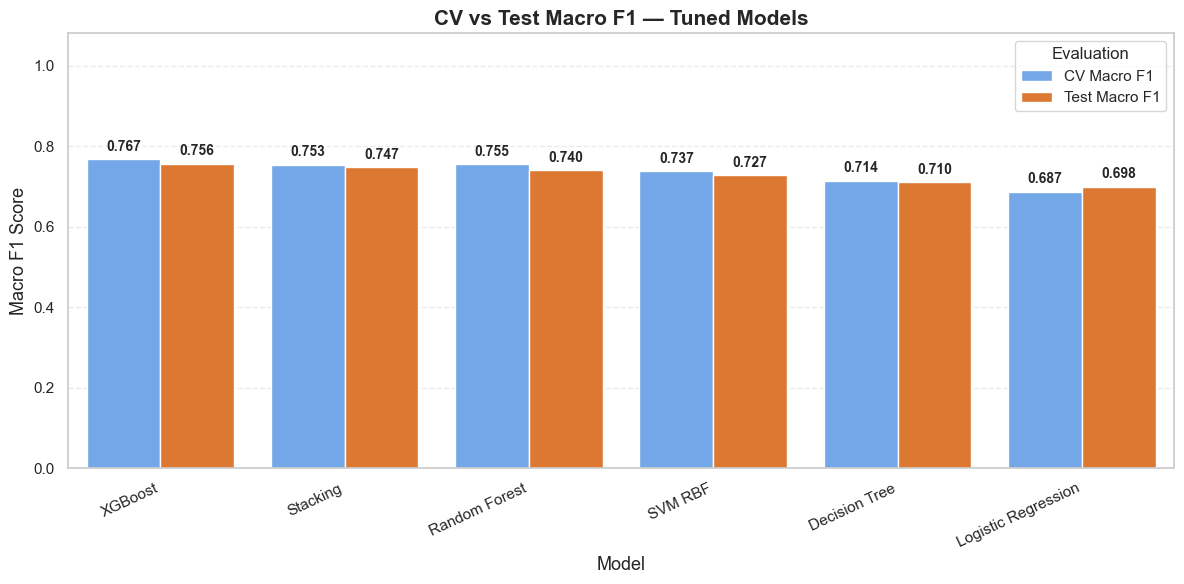

In [ ]:
# === 8.2 Model Kararlılığı: CV - Test Makro F1 ===

cv_score_rows = []

search_objects = {
    'Logistic Regression': lr_search,
    'Decision Tree': dt_search,
    'Random Forest': rf_search,
    'SVM RBF': svm_search,
}

if 'xgb_search' in globals() and xgb_search is not None:
    search_objects['XGBoost'] = xgb_search

if 'stack_search' in globals() and stack_search is not None:
    search_objects['Stacking'] = stack_search

for model_name, search_obj in search_objects.items():
    tuned_row = comparison_df[comparison_df['Base Model'] == model_name]
    
    if len(tuned_row) > 0:
        cv_f1 = search_obj.best_score_
        test_f1 = tuned_row.iloc[0]['Macro F1 Tuned']
        gap = cv_f1 - test_f1
        
        cv_score_rows.append({
            'Model': model_name,
            'CV Macro F1': cv_f1,
            'Test Macro F1': test_f1,
            'Gap (CV - Test)': gap
        })

cv_test_df = pd.DataFrame(cv_score_rows)
cv_test_df = cv_test_df.sort_values('Test Macro F1', ascending=False).reset_index(drop=True)

display(cv_test_df.style.format({
    'CV Macro F1': '{:.4f}',
    'Test Macro F1': '{:.4f}',
    'Gap (CV - Test)': '{:+.4f}'
}))

cv_plot_df = cv_test_df[['Model', 'CV Macro F1', 'Test Macro F1']].melt(
    id_vars='Model',
    var_name='Evaluation',
    value_name='Macro F1'
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=cv_plot_df,
    x='Model',
    y='Macro F1',
    hue='Evaluation',
    palette={
        'CV Macro F1': '#60A5FA',
        'Test Macro F1': '#F97316'
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=4,
        fontsize=10,
        fontweight='bold'
    )

plt.title('CV vs Test Macro F1 — Tuned Modeller', fontsize=15, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('Macro F1 Skoru', fontsize=13)
plt.ylim(0, 1.08)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.legend(title='Evaluation')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 8.3 Sınıf Bazında F1 İyileşmesi

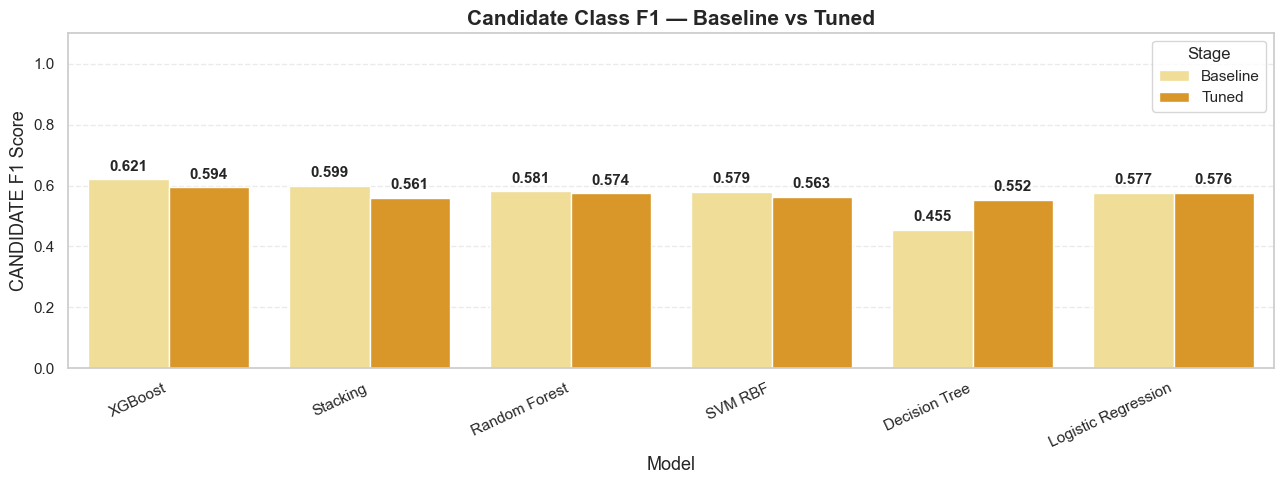

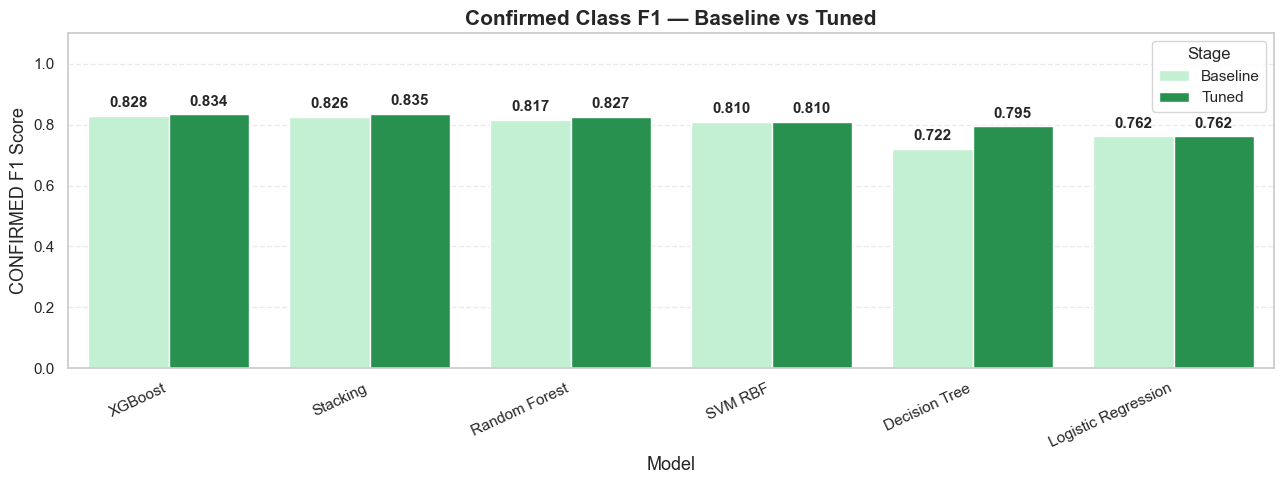

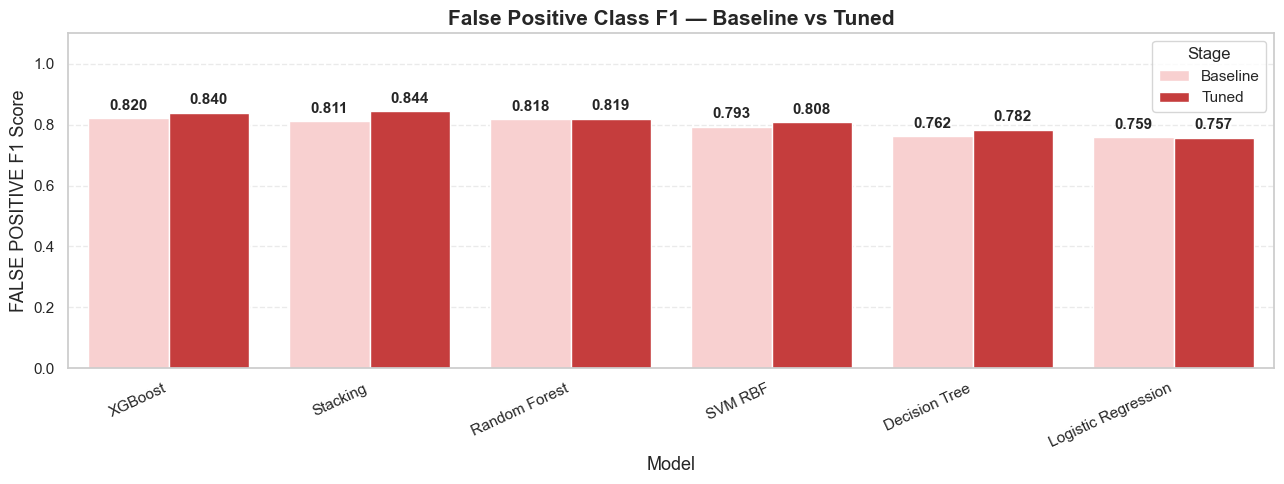

In [ ]:
# === 8.3 Sınıf Bazında F1 — Temel Model - Ayarlanmış Model ===

baseline_predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM RBF': y_pred_svm
}

tuned_predictions = {
    'Logistic Regression': y_pred_lr_tuned,
    'Decision Tree': y_pred_dt_tuned,
    'Random Forest': y_pred_rf_tuned,
    'SVM RBF': y_pred_svm_tuned
}

if XGBOOST_AVAILABLE and 'y_pred_xgb' in globals() and 'y_pred_xgb_tuned' in globals():
    baseline_predictions['XGBoost'] = y_pred_xgb
    tuned_predictions['XGBoost'] = y_pred_xgb_tuned

if 'y_pred_stack_baseline' in globals() and 'y_pred_stack' in globals():
    baseline_predictions['Stacking'] = y_pred_stack_baseline
    tuned_predictions['Stacking'] = y_pred_stack

class_f1_rows = []

for model_name in baseline_predictions.keys():
    if model_name in tuned_predictions:
        baseline_f1_per_class = f1_score(
            y_test,
            baseline_predictions[model_name],
            average=None,
            labels=np.arange(len(le.classes_)),
            zero_division=0
        )

        tuned_f1_per_class = f1_score(
            y_test,
            tuned_predictions[model_name],
            average=None,
            labels=np.arange(len(le.classes_)),
            zero_division=0
        )

        for class_name, baseline_f1, tuned_f1 in zip(
            CLASS_ORDER,
            baseline_f1_per_class,
            tuned_f1_per_class
        ):
            class_f1_rows.append({
                'Model': model_name,
                'Class': class_name,
                'Baseline F1': baseline_f1,
                'Tuned F1': tuned_f1,
                'F1 Improvement': tuned_f1 - baseline_f1
            })

class_f1_compare_df = pd.DataFrame(class_f1_rows)

# Tüm sınıf grafikleri için aynı model sırası; genel ayarlanmış Makro F1'e göre
model_order = (
    comparison_df
    .sort_values('Macro F1 Tuned', ascending=False)['Base Model']
    .tolist()
)

# Yalnızca class_f1_compare_df'de bulunan modelleri tut
model_order = [
    model for model in model_order
    if model in class_f1_compare_df['Model'].unique()
]

class_titles = {
    'CANDIDATE': 'Candidate Class F1 — Baseline vs Tuned',
    'CONFIRMED': 'Confirmed Class F1 — Baseline vs Tuned',
    'FALSE POSITIVE': 'False Positive Class F1 — Baseline vs Tuned'
}

for class_name in CLASS_ORDER:
    class_df = class_f1_compare_df[class_f1_compare_df['Class'] == class_name].copy()

    plot_df = class_df[['Model', 'Baseline F1', 'Tuned F1']].melt(
        id_vars='Model',
        var_name='Stage',
        value_name='F1 Score'
    )

    plot_df['Stage'] = plot_df['Stage'].replace({
        'Baseline F1': 'Baseline',
        'Tuned F1': 'Tuned'
    })

    plt.figure(figsize=(13, 5))

    ax = sns.barplot(
        data=plot_df,
        x='Model',
        y='F1 Score',
        hue='Stage',
        order=model_order,
        palette=class_stage_palettes[class_name]
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=4,
            fontsize=11,
            fontweight='bold'
        )

    plt.title(
        class_titles.get(class_name, f'{class_name} Sınıf F1 — Baseline vs Tuned'),
        fontsize=15,
        fontweight='bold'
    )
    plt.xlabel('Model', fontsize=13)
    plt.ylabel(f'{class_name} F1 Skoru', fontsize=13)
    plt.ylim(0, 1.10)
    plt.xticks(rotation=25, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.legend(title='Stage', title_fontsize=12, fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

## 9. Nihai Model Seçimi

### 9.1 Nihai Model Seçimi

In [ ]:
# En iyi ayarlanmış tahmin ediciyi dinamik olarak seç ve tüm aşağı akış analizlerinde yeniden kullan
# Ayarlanmış tahmin edicileri sözlüğe topla, sonra en iyisini seç
estimator_lookup = {}

if 'lr_search' in globals() and lr_search is not None:
    estimator_lookup['Logistic Regression (Tuned)'] = lr_search.best_estimator_
if 'dt_search' in globals() and dt_search is not None:
    estimator_lookup['Decision Tree (Tuned)'] = dt_search.best_estimator_
if 'rf_search' in globals() and rf_search is not None:
    estimator_lookup['Random Forest (Tuned)'] = rf_search.best_estimator_
if XGBOOST_AVAILABLE and 'xgb_search' in globals() and xgb_search is not None:
    estimator_lookup['XGBoost (Tuned)'] = xgb_search.best_estimator_
if 'svm_search' in globals() and svm_search is not None:
    estimator_lookup['SVM RBF (Tuned)'] = svm_search.best_estimator_
if 'stacking_model' in globals() and stacking_model is not None:
    estimator_lookup['Stacking (Tuned Ensemble)'] = stacking_model

if tuned_df.empty:
    raise ValueError('No tuned models available. Run tuning cells first.')

final_model_row = tuned_df.sort_values('Macro F1', ascending=False).iloc[0]
final_model_name = final_model_row['Model']
final_f1 = final_model_row['Macro F1']

if final_model_name not in estimator_lookup:
    raise ValueError(f'Best tuned estimator not found for {final_model_name}.')

final_estimator = estimator_lookup[final_model_name]

# Tüm nihai analizlerde kullanılan tek kaynaklı nihai tahminler ve skorlar
final_y_pred = final_estimator.predict(X_test)

if hasattr(final_estimator, 'predict_proba'):
    final_y_score = final_estimator.predict_proba(X_test)
elif hasattr(final_estimator, 'decision_function'):
    final_y_score = final_estimator.decision_function(X_test)
    if final_y_score.ndim == 1:
        final_y_score = np.vstack([1 - final_y_score, final_y_score]).T
else:
    final_y_score = None

print('\n' + '=' * 80)
print('FINAL MODEL SEÇİMİ')
print('=' * 80)

print(f'\nSeçilen Model: {final_model_name}')
print(f'Macro F1 (main metric): {final_f1:.4f}')
print(f'Accuracy: {final_model_row["Accuracy"]:.4f}')
print(f'Macro Precision: {final_model_row["Macro Precision"]:.4f}')
print(f'Macro Recall: {final_model_row["Macro Recall"]:.4f}')
print(f'Weighted F1: {final_model_row["Weighted F1"]:.4f}')

print(f'\nEğitim Süresi Analizi:')
if final_model_name == 'XGBoost (Tuned)' and XGBOOST_AVAILABLE and 'xgb_search' in globals() and xgb_search is not None:
    print('  - Optuna tarafından seçilen hiperparametreler kullanılarak final model tüm eğitim seti üzerinde yeniden eğitildi')
    print(f'  - Optuna en iyi CV F1 (macro): {xgb_search.best_score_:.4f}')
else:
    print('  - Final model, tuned model karşılaştırması aşamasında kullanılan modelden yeniden alınmıştır')

print(f'\n✓ Final model olarak {final_model_name} seçildi ve detaylı analiz için hazır')


FINAL MODEL SELECTION

Selected Model: XGBoost (Tuned)
Macro F1 (main metric): 0.7560
Accuracy: 0.7815
Macro Precision: 0.7524
Macro Recall: 0.7650
Weighted F1: 0.7873

Training Time Analysis:
  - Final estimator refit on full training split using Optuna-selected hyperparameters
  - Optuna best CV F1 (macro): 0.7670

✓ Final XGBoost (Tuned) model selected and ready for detailed analysis


## 10. Nihai Model Analizi

### 10.1 Nihai Sınıflandırma Raporu

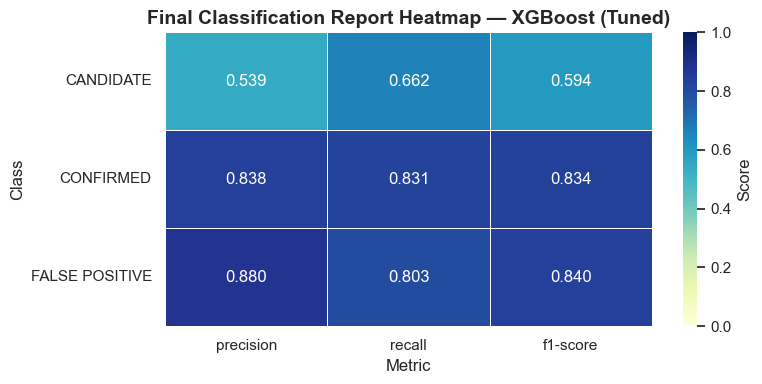

In [ ]:
# === 10.1 Nihai Sınıflandırma Raporu Isı Haritası ===

# Sınıflandırma raporunu ısı haritası olarak görselleştir
report_dict = classification_report(
    y_test,
    final_y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

# Yalnızca sınıf satırlarını ve ana metrikleri tut
class_report_df = report_df.loc[CLASS_ORDER, ['precision', 'recall', 'f1-score']]

plt.figure(figsize=(8, 4))

sns.heatmap(
    class_report_df,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
)

plt.title(f'Final Sınıflandırma Raporu Heatmap — {final_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

### 10.2 Nihai Karışıklık Matrisi

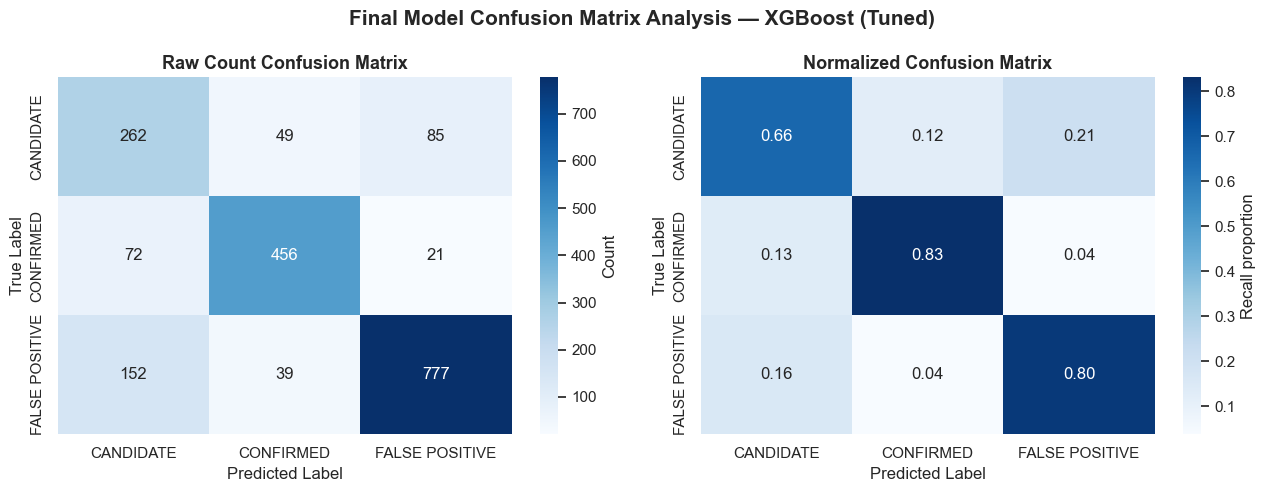

In [ ]:
# === 10.2 Çift Karışıklık Matrisi: Ham Sayı ve Normalize Edilmiş ===

# Ham sayı ve normalize edilmiş karışıklık matrislerini yan yana çiz
cm = confusion_matrix(y_test, final_y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=axes[0],
    cbar_kws={'label': 'Count'}
)

axes[0].set_title('Ham Değerli Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=axes[1],
    cbar_kws={'label': 'Recall proportion'}
)

axes[1].set_title('Normalize Edilmiş Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle(f'Final Model Confusion Matrix Analizi — {final_model_name}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.4 Modelin Ayırt Etme Gücü (ROC ve PR Eğrileri)

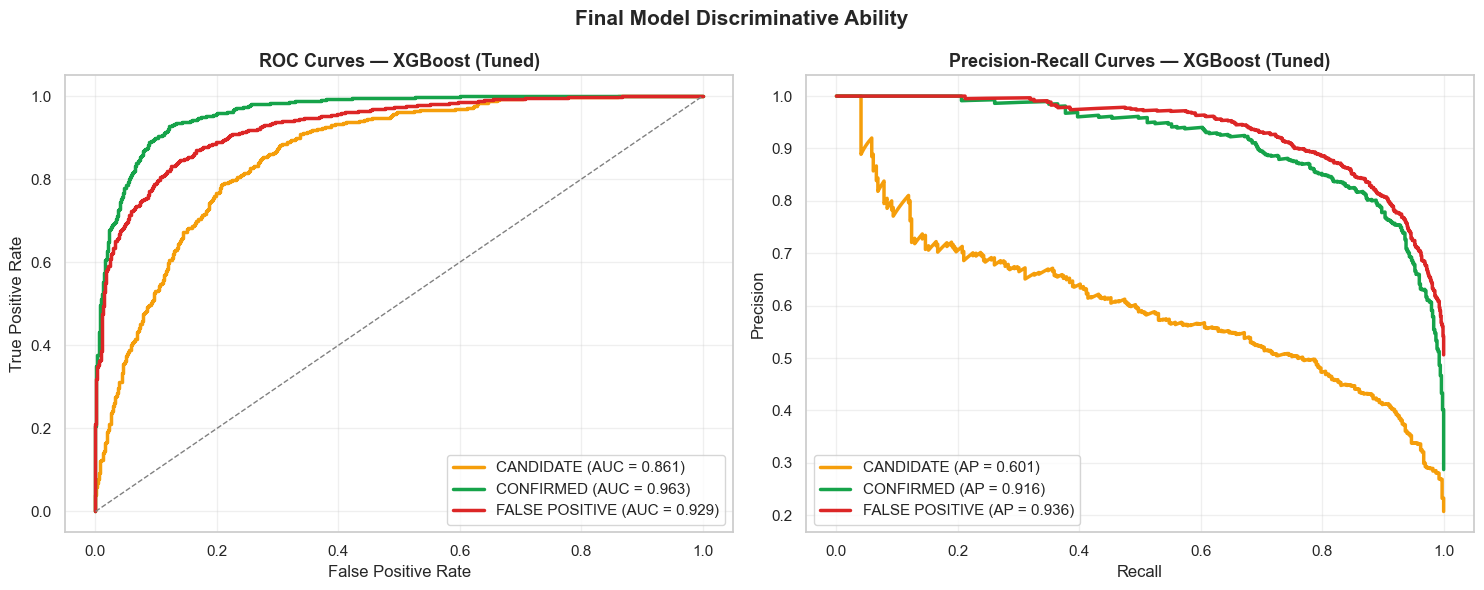

In [ ]:
# === 10.4 Modelin Ayırt Etme Gücü (ROC ve PR Eğrileri) ===

if final_y_score is not None:
    y_test_bin = label_binarize(y_test, classes=np.arange(len(CLASS_ORDER)))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ROC Eğrileri
    for i, class_name in enumerate(CLASS_ORDER):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], final_y_score[:, i])
        roc_auc = auc(fpr, tpr)

        axes[0].plot(
            fpr,
            tpr,
            linewidth=2.5,
            color=CLASS_PALETTE[class_name],
            label=f'{class_name} (AUC = {roc_auc:.3f})'
        )

    axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=1, color='gray')
    axes[0].set_title(f'ROC Eğrisi — {final_model_name}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Hassasiyet-Geri Çağırma Eğrileri
    for i, class_name in enumerate(CLASS_ORDER):
        precision, recall, _ = precision_recall_curve(
            y_test_bin[:, i],
            final_y_score[:, i]
        )
        avg_precision = average_precision_score(
            y_test_bin[:, i],
            final_y_score[:, i]
        )

        axes[1].plot(
            recall,
            precision,
            linewidth=2.5,
            color=CLASS_PALETTE[class_name],
            label=f'{class_name} (AP = {avg_precision:.3f})'
        )

    axes[1].set_title(f'Precision-Recall Eğrisi — {final_model_name}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('Final Model Ayırt Etme Gücü', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print(f'ROC ve Precision-Recall eğrileri {final_model_name} için mevcut değil.')
    print('Final estimator, predict_proba veya decision_function çıktıları sağlamıyor.')

### 10.5 Güven Kalibrasyon Grafiği

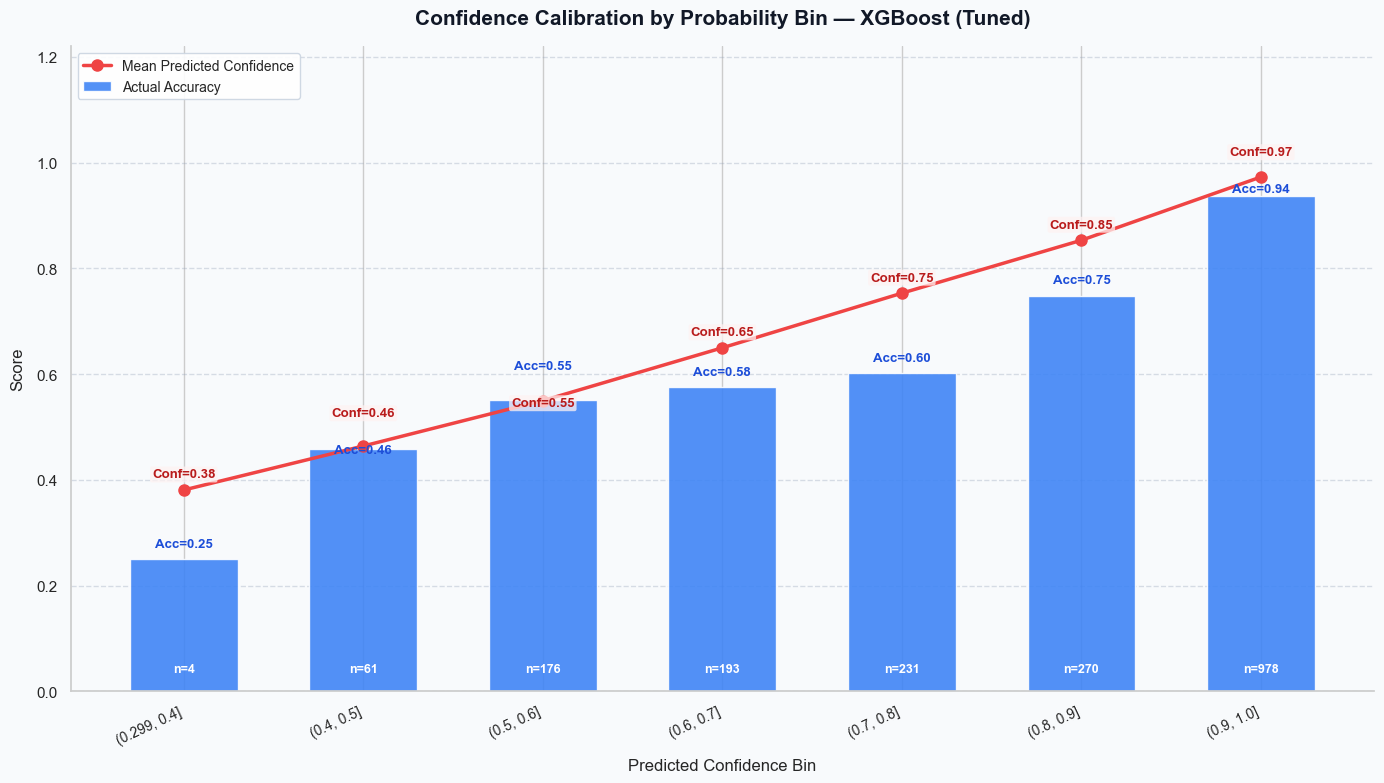

In [ ]:
# === 10.x Güven Kalibrasyon Grafiği — Dinamik Etiket Konumlandırma ===

if final_y_score is not None:
    # Tahmin güven skorlarını olasılık dilimlerine göre gruplandır ve doğrulukla karşılaştır
    final_confidence = np.max(final_y_score, axis=1)
    correct_predictions = (final_y_pred == y_test)

    confidence_bin_df = pd.DataFrame({
        'Confidence': final_confidence,
        'Correct': correct_predictions.astype(int)
    })

    bins = np.arange(0.3, 1.01, 0.1)
    confidence_bin_df['Confidence Bin'] = pd.cut(
        confidence_bin_df['Confidence'],
        bins=bins,
        include_lowest=True
    )

    calibration_table = confidence_bin_df.groupby(
        'Confidence Bin', observed=True
    ).agg(
        Count=('Correct', 'count'),
        Accuracy=('Correct', 'mean'),
        Mean_Confidence=('Confidence', 'mean')
    ).reset_index()

    calibration_table['Confidence Bin Label'] = calibration_table['Confidence Bin'].astype(str)

    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('#F8FAFC')
    ax.set_facecolor('#F8FAFC')

    x = np.arange(len(calibration_table))

    # --- Barlar ---
    ax.bar(
        x,
        calibration_table['Accuracy'],
        width=0.6,
        color='#3B82F6',
        alpha=0.88,
        label='Actual Accuracy',
        zorder=2
    )

    # --- Kırmızı çizgi ---
    ax.plot(
        x,
        calibration_table['Mean_Confidence'],
        color='#EF4444',
        marker='o',
        linewidth=2.5,
        markersize=8,
        label='Mean Predicted Confidence',
        zorder=3
    )

    MIN_GAP = 0.07   # iki etiket arasında garanti edilecek minimum mesafe
    OFFSET  = 0.018  # her etiketin kendi referans noktasından yukarı boşluğu

    for i, row in calibration_table.iterrows():
        accuracy  = row['Accuracy']
        mean_conf = row['Mean_Confidence']
        count     = int(row['Count'])

        # Hangisi daha yüksekte?
        top_val    = max(accuracy, mean_conf)
        bottom_val = min(accuracy, mean_conf)

        top_y    = top_val    + OFFSET
        bottom_y = bottom_val + OFFSET

        # Çakışıyorsa alt etiketi aşağı, üst etiketi yukarı it
        if top_y - bottom_y < MIN_GAP:
            mid = (top_y + bottom_y) / 2
            top_y    = mid + MIN_GAP / 2
            bottom_y = mid - MIN_GAP / 2

        # Hangi değer hangisi?
        if accuracy >= mean_conf:
            acc_y, conf_y = top_y, bottom_y
        else:
            acc_y, conf_y = bottom_y, top_y

        # Accuracy etiketi
        ax.text(
            i, acc_y,
            f'Acc={accuracy:.2f}',
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold',
            color='#1D4ED8', zorder=4
        )

        # Conf etiketi
        ax.text(
            i, conf_y,
            f'Conf={mean_conf:.2f}',
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold',
            color='#B91C1C', zorder=4,
            bbox=dict(boxstyle='round,pad=0.15', fc='#FEF2F2', ec='none', alpha=0.75)
        )

        # n= etiketi — barın içinde
        ax.text(
            i, 0.03,
            f'n={count}',
            ha='center', va='bottom',
            fontsize=9, color='white',
            fontweight='bold', zorder=4
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        calibration_table['Confidence Bin Label'],
        rotation=25, ha='right', fontsize=10
    )
    ax.set_ylim(0, 1.22)
    ax.set_title(
        f'Olasılık Aralıklarına Göre Güven Kalibrasyonu — {final_model_name}',
        fontsize=15, fontweight='bold', pad=16, color='#111827'
    )
    ax.set_xlabel('Tahmin Edilen Güven Aralığı', fontsize=12, labelpad=8)
    ax.set_ylabel('Skor', fontsize=12, labelpad=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.35, color='#94A3B8', zorder=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='#CBD5E1', loc='upper left')

    plt.tight_layout()
    plt.show()

else:
    print('final_y_score değeri None olduğu için güven kalibrasyonu grafiği oluşturulamıyor.')

## 11. SHAP Analizi

In [ ]:
# === 11.1 SHAP Kurulumu ===

print('\n' + '=' * 80)
print('SHAP KURULUMU')
print('=' * 80)

print(f'Final model: {final_model_name}')
print(f'SHAP kullanılabilir: {SHAP_AVAILABLE}')

# Pipeline'dan gerçek modeli çıkar
final_model = (
    final_estimator.named_steps['model']
    if hasattr(final_estimator, 'named_steps') and 'model' in final_estimator.named_steps
    else final_estimator
)

# SHAP için ön işlenmiş test verisini hazırla
# Önemli: SMOTE bir örnekleyici olduğundan (dönüştürücü değil) atlanır.
if hasattr(final_estimator, 'named_steps'):
    X_test_shap_temp = X_test.copy()
    feature_names_shap = X_test.columns.tolist()

    for step_name, step in final_estimator.named_steps.items():
        if step_name == 'model':
            break

        if step_name == 'smote':
            print('  → SHAP veri hazırlığı için SMOTE atlanıyor')
            continue

        if hasattr(step, 'transform'):
            X_test_shap_temp = step.transform(X_test_shap_temp)

            if isinstance(X_test_shap_temp, pd.DataFrame):
                feature_names_shap = X_test_shap_temp.columns.tolist()
            else:
                X_test_shap_temp = pd.DataFrame(
                    X_test_shap_temp,
                    columns=feature_names_shap,
                    index=X_test.index
                )
        else:
            print(f'  → Skipping {step_name}: no transform method')

    X_test_shap_df = X_test_shap_temp.copy()

else:
    X_test_shap_df = X_test.copy()
    feature_names_shap = X_test.columns.tolist()

# Daha hızlı SHAP analizi için örneklem kullan
shap_sample_size = min(500, X_test_shap_df.shape[0])

X_test_shap_sample = X_test_shap_df.sample(
    n=shap_sample_size,
    random_state=RANDOM_STATE
)

print(f'\nSHAP sample boyutu: {shap_sample_size}')
print(f'Özellik sayısı: {len(feature_names_shap)}')

if not SHAP_AVAILABLE:
    print('\n⚠️ SHAP kullanılabilir değil. Kurmak için: pip install shap')

elif hasattr(final_model, 'feature_importances_'):
    print('\n✓ Nihai model ağaç tabanlı ve SHAP TreeExplainer için uygundur.')
    print('✓ SHAP girdi verisi başarıyla hazırlandı.')

else:
    print('\n⚠️ Nihai model doğrudan TreeExplainer SHAP analizini desteklemiyor olabilir.')
    print('   SHAP, XGBoost, Random Forest ve Decision Tree gibi ağaç tabanlı modeller için en uygun olanıdır.')


SHAP SETUP
Final model: XGBoost (Tuned)
SHAP available: True
  → Skipping SMOTE for SHAP data preparation

SHAP sample size: 500
Number of features: 19

✓ Final model is tree-based and suitable for SHAP TreeExplainer.
✓ SHAP input data prepared successfully.


### 11.2 SHAP Global Özellik Önemi

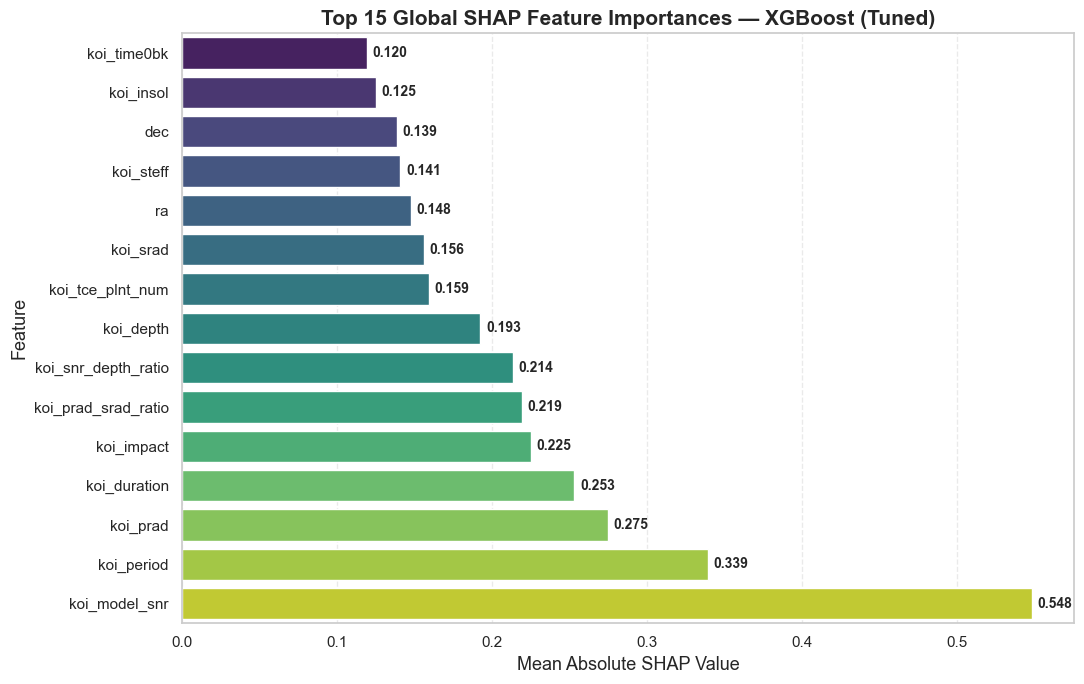

✓ SHAP global feature importance completed.
  → Higher mean absolute SHAP value means stronger overall impact on model predictions.


In [ ]:
# === 11.2 SHAP Global Özellik Önemi ===

if SHAP_AVAILABLE and hasattr(final_model, 'feature_importances_'):

    # Nihai ağaç tabanlı model için SHAP açıklayıcısı oluştur
    # Ağaç tabanlı model için SHAP açıklayıcısını oluştur ve global özellik önemini hesapla
    explainer = shap.TreeExplainer(final_model)

    # Hazırlanan test örneklemi üzerinde SHAP değerlerini hesapla
    shap_values = explainer.shap_values(X_test_shap_sample)

    # Çok sınıflı SHAP çıktısını işle
    # XGBoost çok sınıflı çıktı şu iki biçimde gelebilir:
    # 1) Dizi listesi: [sinif_0_degerleri, sinif_1_degerleri, sinif_2_degerleri]
    # 2) Şekli (örnekler, özellikler, sınıflar) olan dizi
    if isinstance(shap_values, list):
        mean_abs_shap = np.mean(
            [np.abs(class_values).mean(axis=0) for class_values in shap_values],
            axis=0
        )

    elif len(np.array(shap_values).shape) == 3:
        mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_importance_df = pd.DataFrame({
        'Feature': X_test_shap_sample.columns,
        'Mean |SHAP value|': mean_abs_shap
    }).sort_values('Mean |SHAP value|', ascending=False)

    top_shap_features = shap_importance_df.head(15).sort_values(
        'Mean |SHAP value|',
        ascending=True
    )

    plt.figure(figsize=(11, 7))

    ax = sns.barplot(
        data=top_shap_features,
        x='Mean |SHAP value|',
        y='Feature',
        hue='Feature',
        palette='viridis',
        legend=False
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=4,
            fontsize=10,
            fontweight='bold'
        )

    plt.title(
        f'En Önemli 15 Global SHAP Özellik — {final_model_name}',
        fontsize=15,
        fontweight='bold'
    )
    plt.xlabel('Ortalama Mutlak SHAP Değeri', fontsize=13)
    plt.ylabel('Özellik', fontsize=13)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print('✓ SHAP global özellik önem analizi tamamlandı.')
    print('  → Daha yüksek ortalama mutlak SHAP değeri, model tahminleri üzerindeki daha güçlü genel etkiyi ifade eder.')

else:
    print(f'SHAP global özellik önemi {final_model_name} için mevcut değil.')
    print('Bu bölüm SHAP ve ağaç tabanlı bir nihai model gerektirir.')

### 11.3 SHAP Özet / Beeswarm Grafiği

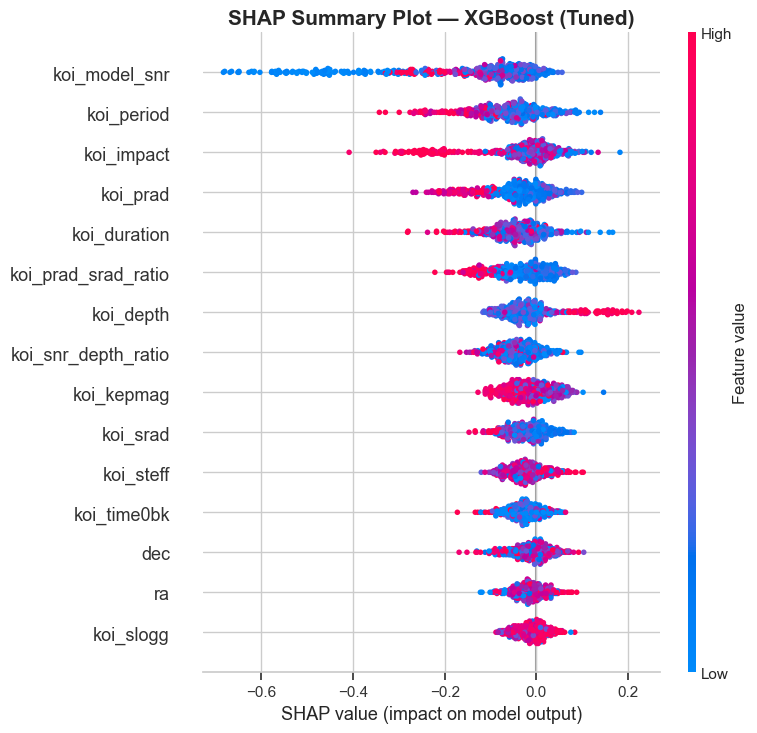

In [ ]:
# === 11.3 SHAP Özet / Beeswarm Grafiği ===

if SHAP_AVAILABLE and 'shap_values' in globals():

    # SHAP özet/beeswarm grafiğini çiz; her özelliğin model üzerindeki genel etkisini gösterir
    shap_array = np.array(shap_values)

    # Çok sınıflı SHAP işleme
    if isinstance(shap_values, list):
        # liste: [sinif_0, sinif_1, sinif_2], her biri şekil = örnekler x özellikler
        shap_values_for_summary = np.mean(np.array(shap_values), axis=0)

    elif shap_array.ndim == 3:
        # dizi: örnekler x özellikler x sınıflar
        shap_values_for_summary = np.mean(shap_array, axis=2)

    else:
        shap_values_for_summary = shap_array

    shap.summary_plot(
        shap_values_for_summary,
        X_test_shap_sample,
        feature_names=X_test_shap_sample.columns,
        max_display=15,
        show=False
    )

    plt.title(
        f'SHAP Özet Grafiği — {final_model_name}',
        fontsize=15,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

else:
    print('SHAP özet grafiği mevcut değil.')
    print('Önce SHAP global özellik önemini çalıştırın.')

### 11.4 Sınıf Bazında SHAP Özellik Önemi

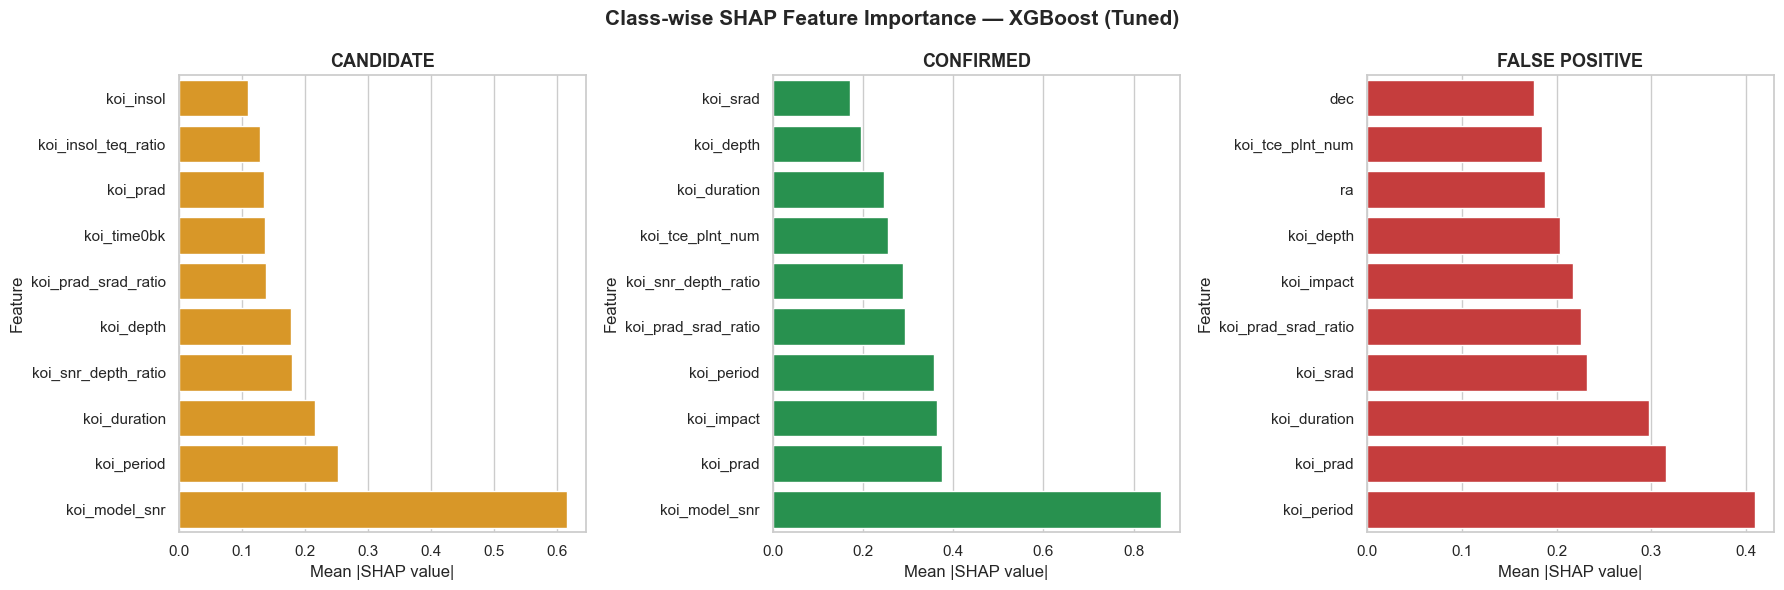

In [ ]:
# === 11.4 Sınıf Bazında SHAP Özellik Önemi ===

if SHAP_AVAILABLE and 'shap_values' in globals():

    # Her sınıf için ayrı SHAP özellik önem grafiği çiz
    shap_array = np.array(shap_values)

    class_importance_rows = []

    if isinstance(shap_values, list):
        # Sınıf dizileri listesi olarak SHAP çıktısı
        for class_idx, class_name in enumerate(CLASS_ORDER):
            mean_abs = np.abs(shap_values[class_idx]).mean(axis=0)

            for feature, value in zip(X_test_shap_sample.columns, mean_abs):
                class_importance_rows.append({
                    'Class': class_name,
                    'Feature': feature,
                    'Mean |SHAP value|': value
                })

    elif shap_array.ndim == 3:
        # Genellikle şekil: örnekler x özellikler x sınıflar
        for class_idx, class_name in enumerate(CLASS_ORDER):
            mean_abs = np.abs(shap_array[:, :, class_idx]).mean(axis=0)

            for feature, value in zip(X_test_shap_sample.columns, mean_abs):
                class_importance_rows.append({
                    'Class': class_name,
                    'Feature': feature,
                    'Mean |SHAP value|': value
                })

    else:
        print('SHAP çıktısı çok sınıflı olmadığı için sınıf bazlı SHAP analizi kullanılamıyor.')

    if class_importance_rows:
        class_shap_df = pd.DataFrame(class_importance_rows)

        fig, axes = plt.subplots(1, len(CLASS_ORDER), figsize=(18, 6), sharex=False)

        for ax, class_name in zip(axes, CLASS_ORDER):
            top_class_features = (
                class_shap_df[class_shap_df['Class'] == class_name]
                .sort_values('Mean |SHAP value|', ascending=False)
                .head(10)
                .sort_values('Mean |SHAP value|', ascending=True)
            )

            sns.barplot(
                data=top_class_features,
                x='Mean |SHAP value|',
                y='Feature',
                ax=ax,
                color=CLASS_PALETTE[class_name]
            )

            ax.set_title(f'{class_name}', fontsize=13, fontweight='bold')
            ax.set_xlabel('Mean |SHAP value|')
            ax.set_ylabel('Feature')

        plt.suptitle(
            f'Sınıf Bazında SHAP Özellik Önemi — {final_model_name}',
            fontsize=15,
            fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

else:
    print('Sınıf bazlı SHAP özellik önemi mevcut değil.')

### Özet

In [ ]:
# İş akışının tüm adımlarını özetleyen raporu yazdır
print('\n' + '=' * 80)
print('MAKİNE ÖĞRENMESİ İŞ AKIŞI — FİNAL ÖZETİ')
print('=' * 80)

# Clean result tables
baseline_summary_df = baseline_df.drop_duplicates(subset='Model', keep='last').copy()
tuned_summary_df = tuned_df.drop_duplicates(subset='Model', keep='last').copy()

best_baseline_model = baseline_summary_df.iloc[0]['Model']
best_baseline_f1 = baseline_summary_df.iloc[0]['Macro F1']

best_tuned_model = tuned_summary_df.iloc[0]['Model']
best_tuned_f1 = tuned_summary_df.iloc[0]['Macro F1']

print('\n1. VERİ SETİ')
print(f'   - Toplam örnek sayısı: {len(df)}')
print(f'   - Nihai sayısal özellikler: {len(numeric_cols)}')
print(f'   - Hedef sınıflar: {len(le.classes_)}')
print(f'   - Sınıf etiketleri: {", ".join(le.classes_)}')
print('   - Sınıf dağılımı: Orta derecede dengesiz')

print('\n2. ÖZELLİK SEÇİMİ VE ÖN İŞLEME')
print(f'   - Leakage sütunları kaldırıldı: {len(leakage_cols)}')
print(f'   - Metadata sütunları kaldırıldı: {len(id_meta_cols)}')
print(f'   - Mühendislik oranı özellikleri eklendi: {len(new_cols) if "new_cols" in globals() else "N/A"}')
print(f'   - Çarpık özellikler log-dönüştürüldü: {len(skewed_cols)}')
print('   - Eksik değerler medyan ile dolduruldu')
print('   - Aykırı değerler eğitim seti yüzdelikleri kullanılarak kesildi')
print('   - Özellikler StandardScaler ile standartlaştırıldı')
print('   - SMOTE yalnızca eğitim boru hattı içinde uygulandı')
print('   - Stratified 80/20 train-test split kullanıldı')
print('   - Tüm ön işleme dönüştürücüleri yalnızca eğitim verilerine uyarlandı')

print(f'\n3. BASELINE MODELS ({len(baseline_summary_df)} models)')
print(f'   - En iyi baseline model: {best_baseline_model}')
print(f'   - En iyi baseline Macro F1: {best_baseline_f1:.4f}')

print('\n4. HİPERPARAMETRE OPTİMİZASYONU')
print('   - Logistic Regression: GridSearchCV')
print('   - Decision Tree: GridSearchCV')
print('   - Random Forest: RandomizedSearchCV')
print('   - XGBoost: Optuna optimization' if XGBOOST_AVAILABLE else '   - XGBoost: Not available')
print('   - SVM RBF: RandomizedSearchCV')
if 'stacking_model' in globals() and stacking_model is not None:
    print('   - Stacking Ensemble: GridSearchCV')
print(f'   - CV stratejisi: StratifiedKFold ({CV_SPLITS} splits)')
print('   - Ana değerlendirme metriği: f1_macro')

print(f'\n5. TUNED MODELLER PERFORMANSI ({len(tuned_summary_df)} models)')
print(f'   - En iyi tuned model: {best_tuned_model}')
print(f'   - En iyi tuned Macro F1: {best_tuned_f1:.4f}')
print(f'   - En iyi baseline ile iyileşme: {best_tuned_f1 - best_baseline_f1:+.4f}')

print('\n6. FINAL MODELİ SEÇİMİ')
print(f'   - Seçilen final modeli: {final_model_name}')
print(f'   - Macro F1: {final_f1:.4f}')
print(f'   - Accuracy: {final_model_row["Accuracy"]:.4f}')
print(f'   - Macro Precision: {final_model_row["Macro Precision"]:.4f}')
print(f'   - Macro Recall: {final_model_row["Macro Recall"]:.4f}')
print(f'   - Weighted F1: {final_model_row["Weighted F1"]:.4f}')

print('\n7. FINAL MODELİ ANALİZİ')
print('   ✓ Final sınıflandırma raporu')
print('   ✓ Ham ve normalize edilmiş karmaşıklık matrisleri')
print('   ✓ Özellik önem analizi')
print('   ✓ ROC ve Precision-Recall eğrileri')
print('   ✓ Tahmin güveni dağılımı')
print('   ✓ Güven kalibrasyonu olasılık binine göre')

if SHAP_AVAILABLE and hasattr(final_model, 'feature_importances_'):
    print('   ✓ SHAP Global Özellik Önem Analizi')
    print('   ✓ SHAP özet grafiği')
    print('   ✓ Sınıf bazında SHAP özellik önemi')
    print('   ✓ SHAP bağımlılık grafiği')
else:
    print('   • SHAP analizi geçerli değil veya mevcut değil')

print('\n8. ANA BULGULAR')
print('   - Final model, CONFIRMED ve FALSE POSITIVE sınıflarında güçlü performans gösteriyor.')
print('   - CANDIDATE, diğer sınıflarla örtüşme nedeniyle en zor sınıf olmaya devam ediyor.')
print('   - Olasılık skorları faydalı, ancak mükemmel bir şekilde kalibre edilmemiş.')
print('   - Tahmin edilen olasılıklar, kesin bilimsel olasılıklar değil, model güven skorları olarak yorumlanmalıdır.')

print('\n' + '=' * 80)
print('✓ WORKFLOW TAMAMLANDI')
print('=' * 80)


MACHINE LEARNING WORKFLOW — FINAL SUMMARY

1. DATASET
   - Total samples: 9564
   - Final numeric features: 19
   - Target classes: 3
   - Class labels: CANDIDATE, CONFIRMED, FALSE POSITIVE
   - Class distribution: Moderately imbalanced

2. FEATURE SELECTION AND PREPROCESSING
   - Leakage columns removed: 6
   - Metadata columns removed: 4
   - Engineered ratio features added: 3
   - Skewed features log-transformed: 15
   - Missing values handled with median imputation
   - Outliers clipped using training-set percentiles
   - Features standardized with StandardScaler
   - SMOTE applied inside the training pipeline only
   - Stratified 80/20 train-test split used
   - All preprocessing transformers fitted on training data only

3. BASELINE MODELS (6 models)
   - Best baseline model: XGBoost (Baseline)
   - Best baseline Macro F1: 0.7565

4. HYPERPARAMETER OPTIMIZATION
   - Logistic Regression: GridSearchCV
   - Decision Tree: GridSearchCV
   - Random Forest: RandomizedSearchCV
   - XGB

### Temel Bulgular

In [ ]:
# Analizden çıkarılan temel bulguları yazdır
print('\n' + '=' * 80)
print('TEMEL BULGULAR')
print('=' * 80)

print('\n1. Sınıf Dengesizliği ve Değerlendirme Stratejisi')
print('   - Veri seti, orta derecede dengesiz bir hedef dağılımına sahiptir.')
print('   - Her sınıfa eşit önem vermek için ana metrik olarak Macro F1 seçilmiştir.')
print('   - Stratified train-test split kullanılarak hem eğitim hem de test setlerinde sınıf oranları korunmuştur.')

print('\n2. Özellik Desenleri ve Ön İşleme')
print('   - Birkaç sayısal özellik güçlü sağa çarpıklık ve aşırı değerler gösterdi.')
print('   - Log1p dönüşümü ve yüzdelik tabanlı kesme, çarpıklığı önemli ölçüde azalttı.')
print('   - Medyan ile doldurma, log dönüşümü, kesme, ölçekleme ve SMOTE, Pipeline nesneleri içinde uygulandı.')
print('   - Leakage ile ilgili sütunlar ve meta veri tanımlayıcıları eğitimden önce kaldırıldı.')
print('   - Seçilen özellik setinde ciddi çoklu bağlantı tespiti yapılmadı.')

print('\n3. Özellik Mühendisliği')
if 'new_cols' in globals():
    print(f'   - {len(new_cols)} mühendislik oranı özelliği eklendi: {", ".join(new_cols)}.')
else:
    print('   - Mühendislik oranı özellikleri, alanla ilgili ilişkileri yakalamak için eklendi.')
print('   - Bu özellikler, hedef bilgisini kullanmadan eğitim ve test setleri için tutarlı bir şekilde oluşturuldu.')

print('\n4. Model Performansı')
print(f'   - En iyi baseline model: {best_baseline_model} (Macro F1 = {best_baseline_f1:.4f})')
print(f'   - En iyi tuned model: {best_tuned_model} (Macro F1 = {best_tuned_f1:.4f})')
print(f'   - Seçilen final model: {final_model_name} (Macro F1 = {final_f1:.4f})')
print(f'   - En iyi baseline ile iyileşme: {best_tuned_f1 - best_baseline_f1:+.4f}')

if 'comparison_df' in globals() and 'Macro F1 İyileşme' in comparison_df.columns:
    improved_count = (comparison_df['Macro F1 İyileşme'] > 0).sum()
    print(f'   - Başlangıç–tuned karşılaştırmasında, {len(comparison_df)} eşleşen model çiftinin {improved_count} tanesinde Macro F1 iyileşmiştir')

print('\n5. Sınıf Bazında Davranış')
print('   - CONFIRMED ve FALSE POSITIVE sınıfları genellikle daha güvenilir bir şekilde sınıflandırıldı.')
print('   - CANDIDATE, sınıflandırılması en zor sınıf olmaya devam etti.')
print('   - Bu beklenen bir durumdur çünkü CANDIDATE gözlemleri doğal olarak belirsizdir ve hem CONFIRMED hem de FALSE POSITIVE desenleri ile örtüşmektedir.')
print('   - Sınıf bazında F1 analizi, ayarlamanın tüm sınıfları eşit şekilde iyileştirmediğini göstermiştir.')

print('\n6. Olasılık ve Güven Güvenilirliği')
print('   - ROC ve Precision-Recall eğrileri, CONFIRMED ve FALSE POSITIVE için güçlü ayrılabilirlik gösterdi.')
print('   - CANDIDATE, daha zayıf Precision-Recall performansına sahipti ve bu da onun en belirsiz sınıf olduğunu doğruladı.')
print('   - Güven kalibrasyonu analizi, modelin genellikle yüksek güven seviyelerinde daha doğru olduğunu gösterdi.')
print('   - Ancak, tahmin edilen olasılıklar mükemmel bir şekilde kalibre edilmemiştir ve kesin bilimsel olasılıklar yerine model güven skorları olarak yorumlanmalıdır.')

print('\n7. Açıklanabilirlik')
print('   - Özellik önemi ve SHAP analizleri, final modeli yorumlamak için kullanıldı.')
print('   - SHAP sonuçları, model kararlarının sinyal ve geçişle ilgili özelliklerden güçlü bir şekilde etkilendiğini gösterdi.')
print('   - Sınıf bazında SHAP analizi, her hedef sınıf için en etkili özelliklerin belirlenmesine yardımcı oldu.')
print('   - Yerleşik özellik önemi, model düzeyinde sıralama sağlarken, SHAP tahmin düzeyinde katkı analizi sunar.')

print('\n8. Veri Sızıntısı Önleme')
print('   - Dağıtım ile ilgili puanlar ve yanlış pozitif bayraklar gibi sızıntı sütunları kaldırıldı.')
print('   - Tüm ön işleme, Pipeline nesneleri içinde yerleştirildi.')
print('   - Dönüştürücüler yalnızca eğitim verilerine uyarlandı.')
print('   - Kesme sınırları yalnızca eğitim setinden hesaplandı.')
print('   - X_test, hiperparametre ayarlama sırasında asla kullanılmadı.')

print('\n' + '=' * 80)


KEY FINDINGS

1. Class Imbalance and Evaluation Strategy
   - The dataset has a moderately imbalanced target distribution.
   - Macro F1 was selected as the primary metric because it gives equal importance to each class.
   - Stratified train-test split was used to preserve class proportions in both train and test sets.

2. Feature Patterns and Preprocessing
   - Several numeric features showed strong right-skewness and extreme values.
   - Log1p transformation and percentile-based clipping substantially reduced skewness.
   - Median imputation, log transformation, clipping, scaling, and SMOTE were applied inside Pipeline objects.
   - Leakage-related columns and metadata identifiers were removed before training.
   - No severe multicollinearity was detected in the selected feature set.

3. Feature Engineering
   - 3 engineered ratio features were added: koi_prad_srad_ratio, koi_snr_depth_ratio, koi_insol_teq_ratio.
   - These features were created consistently for train and test sets

## 11. Model Kalıcılığı

In [ ]:
# Yeniden üretilebilir çıkarım için seçilen nihai tahmin ediciyi ve meta veriyi kaydet
# Nihai modeli ve meta veriyi joblib ile dışa aktar
export_path = 'final_model.joblib'
ratio_columns = list(new_cols) if 'new_cols' in globals() else []

model_bundle = {
    'model_pipeline': final_estimator,
    'label_encoder': le,
    'class_names': list(le.classes_),
    'target_column': target_col,
    'feature_columns_train': list(X_train.columns),
    'drop_columns': drop_cols,
    'skewed_columns': skewed_cols,
    'random_state': RANDOM_STATE,
    'model_name': final_model_name,
    'ratio_columns': ratio_columns,
}

joblib.dump(model_bundle, export_path)
file_size_kb = os.path.getsize(export_path) / 1024

print('Model dışa aktarma işlemi tamamlandı')
print(f'  - Kaydedilen dosya: {export_path}')
print(f'  - Boyut: {file_size_kb:.1f} KB')
print(f'  - Model: {final_model_name}')
print('  - Eğitilmiş model + encoder + deployment için gerekli metadata')

# Streamlit karşılaştırma uygulaması için bireysel ayarlanmış modelleri ve meta veriyi dışa aktar
os.makedirs('models', exist_ok=True)

model_files = {}
models_to_export = {}

if 'lr_search' in globals() and lr_search is not None:
    model_files['Logistic Regression (Tuned)'] = 'models/logistic_regression_tuned.joblib'
    models_to_export['Logistic Regression (Tuned)'] = lr_search.best_estimator_
    joblib.dump(models_to_export['Logistic Regression (Tuned)'], model_files['Logistic Regression (Tuned)'])

if 'dt_search' in globals() and dt_search is not None:
    model_files['Decision Tree (Tuned)'] = 'models/decision_tree_tuned.joblib'
    models_to_export['Decision Tree (Tuned)'] = dt_search.best_estimator_
    joblib.dump(models_to_export['Decision Tree (Tuned)'], model_files['Decision Tree (Tuned)'])

if 'rf_search' in globals() and rf_search is not None:
    model_files['Random Forest (Tuned)'] = 'models/random_forest_tuned.joblib'
    models_to_export['Random Forest (Tuned)'] = rf_search.best_estimator_
    joblib.dump(models_to_export['Random Forest (Tuned)'], model_files['Random Forest (Tuned)'])

if XGBOOST_AVAILABLE and 'xgb_search' in globals() and xgb_search is not None:
    model_files['XGBoost (Tuned)'] = 'models/xgboost_tuned.joblib'
    models_to_export['XGBoost (Tuned)'] = xgb_search.best_estimator_
    joblib.dump(models_to_export['XGBoost (Tuned)'], model_files['XGBoost (Tuned)'])

if 'svm_search' in globals() and svm_search is not None:
    model_files['SVM RBF (Tuned)'] = 'models/svm_rbf_tuned.joblib'
    models_to_export['SVM RBF (Tuned)'] = svm_search.best_estimator_
    joblib.dump(models_to_export['SVM RBF (Tuned)'], model_files['SVM RBF (Tuned)'])

if 'stacking_model' in globals() and stacking_model is not None:
    model_files['Stacking (Tuned Ensemble)'] = 'models/stacking_tuned_ensemble.joblib'
    models_to_export['Stacking (Tuned Ensemble)'] = stacking_model
    joblib.dump(models_to_export['Stacking (Tuned Ensemble)'], model_files['Stacking (Tuned Ensemble)'])

final_metrics = final_model_row.to_dict()
feature_medians = X_train.median(numeric_only=True).to_dict()
feature_means = X_train.mean(numeric_only=True).to_dict()
feature_std = X_train.std(numeric_only=True).to_dict()
feature_skewness = X_train.skew(numeric_only=True).to_dict()
feature_missing_counts = X_train.isnull().sum().to_dict()

class_distribution = pd.Series(y_train).map(lambda i: le.classes_[i]).value_counts().to_dict()
class_total = sum(class_distribution.values())
class_percentages = {
    class_name: (count / class_total) * 100 if class_total else 0.0
    for class_name, count in class_distribution.items()
}

classification_reports = {}
confusion_matrices = {}
for model_name, estimator in models_to_export.items():
    y_pred_model = estimator.predict(X_test)
    classification_reports[model_name] = classification_report(
        y_test,
        y_pred_model,
        target_names=le.classes_,
        output_dict=True
    )
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred_model).tolist()

feature_importance_table = feat_df.to_dict(orient='records') if 'feat_df' in globals() else []

example_inputs = {}
for class_idx, class_name in enumerate(le.classes_):
    matching_indices = np.where(y_test == class_idx)[0]
    if len(matching_indices) > 0:
        row_idx = matching_indices[0]
        example_inputs[class_name] = X_test.iloc[row_idx].to_dict()

metadata_bundle = {
    'final_model_name': final_model_name,
    'label_encoder': le,
    'class_names': list(le.classes_),
    'target_column': target_col,
    'feature_columns_train': list(X_train.columns),
    'drop_columns': drop_cols,
    'skewed_columns': skewed_cols,
    'ratio_columns': ratio_columns,
    'random_state': RANDOM_STATE,
    'model_files': model_files,
    'final_metrics': final_metrics,
    'feature_medians': feature_medians,
    'feature_means': feature_means,
    'feature_std': feature_std,
    'feature_skewness': feature_skewness,
    'feature_missing_counts': feature_missing_counts,
    'class_distribution': class_distribution,
    'class_percentages': class_percentages,
    'baseline_results_table': baseline_df.to_dict(orient='records'),
    'tuned_results_table': tuned_df.to_dict(orient='records'),
    'comparison_table': comparison_df.to_dict(orient='records'),
    'classification_reports': classification_reports,
    'confusion_matrices': confusion_matrices,
    'feature_importance_table': feature_importance_table,
    'example_inputs': example_inputs,
}

joblib.dump(metadata_bundle, 'models/metadata.joblib')

print('\nStreamlit karşılaştırma çıktıları tamamlandı')
print(f'  - Kaydedilen {len(model_files)} model dosyası models/ dizinine')
print('  - Kaydedilen dosya: models/metadata.joblib')

Model export complete
  - Saved file: final_model.joblib
  - Size: 4502.6 KB
  - Model: XGBoost (Tuned)
  - Includes fitted estimator + encoder + metadata for deployment

Streamlit comparison exports complete
  - Saved 6 model file(s) to models/
  - Saved file: models/metadata.joblib


In [110]:
# Dışa aktarılan meta veri paketinin içeriğini doğrula
metadata_check = joblib.load('models/metadata.joblib')

print(metadata_check.keys())
print(metadata_check['example_inputs'].keys())
print(metadata_check['model_files'].keys())
print(metadata_check['classification_reports'].keys())
print(metadata_check['confusion_matrices'].keys())

dict_keys(['final_model_name', 'label_encoder', 'class_names', 'target_column', 'feature_columns_train', 'drop_columns', 'skewed_columns', 'ratio_columns', 'random_state', 'model_files', 'final_metrics', 'feature_medians', 'feature_means', 'feature_std', 'feature_skewness', 'feature_missing_counts', 'class_distribution', 'class_percentages', 'baseline_results_table', 'tuned_results_table', 'comparison_table', 'classification_reports', 'confusion_matrices', 'feature_importance_table', 'example_inputs'])
dict_keys(['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE'])
dict_keys(['Logistic Regression (Tuned)', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'XGBoost (Tuned)', 'SVM RBF (Tuned)', 'Stacking (Tuned Ensemble)'])
dict_keys(['Logistic Regression (Tuned)', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'XGBoost (Tuned)', 'SVM RBF (Tuned)', 'Stacking (Tuned Ensemble)'])
dict_keys(['Logistic Regression (Tuned)', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'XGBoost (Tuned)', 'SVM 